# Explore downloaded guides + extracted rubrics

**Status (2026-05-20).** Online rubric collection is complete for 11 tasks.
This notebook loads every GPT-5-mini extraction into two tidy frames, walks
through coverage and quality, then connects to the downstream **structural
metrics** computed on the locked clustering. The clustering pipeline itself
and the cross-task findings it produced are documented in
[`notes/2026-05-19__structural-metrics.md`](../notes/2026-05-19__structural-metrics.md);
the L0 → R1 → R2 → R3 grain plan is §7 of that note.

**Current scale (built from this notebook's outputs):**

| stage | count | artifact |
|---|---|---|
| source pages | 38,303 | `notebooks/_explore_cache/pages.parquet` |
| extracted rubrics | 361,050 | `notebooks/_explore_cache/rubrics.parquet` |
| canonical leaves | 53,413 | `outputs/analyses/canon_all_real_forms.jsonl` |
| L0 clusters (tau 0.825) | 33,123 | `outputs/analyses/structural_metrics/clusters_<task>.json` |
| R1 families (peer-review, in progress) | 676 | `outputs/analyses/structural_metrics/r1_families_<task>.json` |

**End-to-end flow:**

```
raw HTML/PDF  →  GPT-5-mini extraction (this notebook)  →  rubrics.parquet
   →  canonicalize (Llama-3.3-70B)  →  canon_all_real_forms.jsonl
   →  judge-distilled LoRA + ModernBERT-CE  →  kNN + blend affinity
   →  average-linkage @ tau 0.825  →  clusters_<task>.json
   →  per-batch LLM grouping  →  r1_families_<task>.json
```

Two tidy dataframes are built here:

- `pages_df`  — one row per source page (orientation, subtask, audience, …)
- `rubrics_df` — one row per extracted rubric (joined back to its source page)

Cached to parquet on first run so subsequent runs are fast. After the basic
exploration we connect to the structural metrics artifacts under
`outputs/analyses/structural_metrics/` and visualize the per-task findings.

**Sections:**

1. Load extractions into tidy frames
2. Coverage & basic counts
3. Sample inspection — HTML cards (peer-review focus)
4. Rubric-count distribution per task
5. Orientation & breadth breakdown
6. Subtask vocabulary
7. Top keywords per task
8. Cross-task duplicate exploration (cheap first pass)
9. Rubric content stats
10. Rubric-density by orientation
11. Error pages QA
12. Flat-CSV export
13. **Structural metrics summary** — concentration, specificity, universal
    concepts, source-consensus, task-family matrix (fed back into this
    notebook from the May-19 pipeline run)


In [549]:
import json
import glob
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/Users/spangher/Projects/stanford-research/norm-research")
DATASETS = ROOT / "datasets"
CACHE = ROOT / "notebooks" / "_explore_cache"
CACHE.mkdir(parents=True, exist_ok=True)

TASKS = [
    "creative-writing", "peer-review", "math-stackexchange", "news-homepages",
    "press-releases", "code-review", "grant-funding", "humor",
    "legal-outcome-prediction", "notice-and-comment", "patents",
]

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

## 1. Load every extraction into tidy frames

Each per-page JSON in `gpt-parsed/gpt-5-mini/` has shape:
```
{path, model, input_tokens, output_tokens, elapsed_s, extracted: {
  orientation, intended_audience, subtask_short, subtask_description,
  subtask_keywords, subtask_breadth, error, rubrics_metrics: [{name, description, guidance}, …]
}}
```

In [550]:
def _collect():
    page_rows = []
    rubric_rows = []
    for task in TASKS:
        d = DATASETS / task / "online-rubrics" / "gpt-parsed" / "gpt-5-mini"
        if not d.is_dir():
            continue
        for fp in d.glob("*.json"):
            if fp.name.startswith("_"):
                continue
            try:
                obj = json.loads(fp.read_text())
            except Exception as e:
                continue
            ex = obj.get("extracted") or {}
            src_name = fp.name[:-5]  # strip ".json"
            # filename is "<source_dir>__<basename>" — pull source dir as first segment
            if "__" in src_name:
                src_dir, src_base = src_name.split("__", 1)
            else:
                src_dir, src_base = "raw", src_name
            # filename prefix hints at which collection wave produced it
            slug = src_base.lower()
            if slug.startswith("rej_"):
                wave_tag = "rej"
            elif slug.startswith("waveh1_") or "waveh1" in slug:
                wave_tag = "h1_wayback"
            elif slug.startswith("waveh2_") or "waveh2" in slug:
                wave_tag = "h2_editions"
            elif slug.startswith("waveh3_") or "waveh3" in slug:
                wave_tag = "h3_archives"
            elif slug.startswith("waveh4_") or "waveh4" in slug:
                wave_tag = "h4_ancient"
            elif slug.startswith("waveh5_") or "waveh5" in slug:
                wave_tag = "h5_20c"
            elif slug.startswith("waveh6_") or "waveh6" in slug:
                wave_tag = "h6_editions"
            elif slug.startswith("waveh7_") or "waveh7" in slug:
                wave_tag = "h7_ml_paper_quality"
            elif slug.startswith("wavee_") or "wavee" in slug:
                wave_tag = "wavee_gap"
            elif slug.startswith("wavec_"):
                wave_tag = "wavec_topup"
            elif slug.startswith("waved_"):
                wave_tag = "waved_topup"
            elif slug.startswith("waveb_") or "waveb" in slug:
                wave_tag = "waveb"
            elif slug.startswith("phase"):
                wave_tag = "phase_initial"
            elif slug.startswith("existing_") or src_dir == "claude-parsed":
                wave_tag = "claude_parsed" if src_dir == "claude-parsed" else "existing"
            else:
                wave_tag = "other"

            error = ex.get("error")
            rubrics = ex.get("rubrics_metrics") or []
            page_id = f"{task}::{src_dir}::{src_base}"
            page_rows.append({
                "page_id": page_id,
                "task": task,
                "source_dir": src_dir,   # 'raw' or 'claude-parsed'
                "source_file": src_base,
                "wave_tag": wave_tag,
                "orientation": ex.get("orientation"),
                "intended_audience": ex.get("intended_audience"),
                "subtask_short": ex.get("subtask_short"),
                "subtask_description": ex.get("subtask_description"),
                "subtask_keywords": ex.get("subtask_keywords") or [],
                "subtask_breadth": ex.get("subtask_breadth"),
                "error": error,
                "is_error": bool(error) or ex.get("orientation") == "error",
                "n_rubrics": len(rubrics),
                "input_tokens": obj.get("input_tokens", 0),
                "output_tokens": obj.get("output_tokens", 0),
                "elapsed_s": obj.get("elapsed_s", 0.0),
            })
            for idx, r in enumerate(rubrics):
                rubric_rows.append({
                    "page_id": page_id,
                    "task": task,
                    "source_dir": src_dir,
                    "orientation": ex.get("orientation"),
                    "subtask_short": ex.get("subtask_short"),
                    "subtask_breadth": ex.get("subtask_breadth"),
                    "rubric_idx": idx,
                    "rubric_name": (r.get("name") or "").strip(),
                    "rubric_description": (r.get("description") or "").strip(),
                    "rubric_guidance": (r.get("guidance") or "").strip(),
                    "name_len": len(r.get("name") or ""),
                    "desc_len": len(r.get("description") or ""),
                    "guidance_len": len(r.get("guidance") or ""),
                })
    return pd.DataFrame(page_rows), pd.DataFrame(rubric_rows)


pages_path = CACHE / "pages.parquet"
rubrics_path = CACHE / "rubrics.parquet"

if pages_path.exists() and rubrics_path.exists():
    pages_df = pd.read_parquet(pages_path)
    rubrics_df = pd.read_parquet(rubrics_path)
    print(f"loaded from cache: {len(pages_df):,} pages, {len(rubrics_df):,} rubrics")
else:
    pages_df, rubrics_df = _collect()
    # Persist (subtask_keywords is a list -> store as JSON string for parquet compat)
    pages_df["subtask_keywords"] = pages_df["subtask_keywords"].apply(json.dumps)
    pages_df.to_parquet(pages_path)
    rubrics_df.to_parquet(rubrics_path)
    pages_df["subtask_keywords"] = pages_df["subtask_keywords"].apply(json.loads)
    print(f"built fresh: {len(pages_df):,} pages, {len(rubrics_df):,} rubrics")

# Make sure keyword column is a list, not JSON string (after reload from parquet)
if isinstance(pages_df["subtask_keywords"].iloc[0], str):
    pages_df["subtask_keywords"] = pages_df["subtask_keywords"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )

loaded from cache: 75,949 pages, 902,882 rubrics


## 2. Coverage & basic counts

In [551]:
coverage = (
    pages_df.groupby("task")
    .agg(
        n_pages=("page_id", "size"),
        n_pages_with_rubrics=("n_rubrics", lambda s: (s > 0).sum()),
        n_error_pages=("is_error", "sum"),
        n_rubrics_total=("n_rubrics", "sum"),
        median_rubrics_per_page=("n_rubrics", "median"),
        mean_rubrics_per_page=("n_rubrics", "mean"),
    )
    .sort_values("n_pages", ascending=False)
)
coverage["error_pct"] = (coverage["n_error_pages"] / coverage["n_pages"] * 100).round(1)
coverage["rubric_yield_pct"] = (coverage["n_pages_with_rubrics"] / coverage["n_pages"] * 100).round(1)
coverage

,n_pages,n_pages_with_rubrics,n_error_pages,n_rubrics_total,median_rubrics_per_page,mean_rubrics_per_page,error_pct,rubric_yield_pct
task,,,,,,,,
news-homepages,8690,3622,1279,58914,0.0,6.779517,14.7,41.7
patents,8178,6190,1636,130214,15.0,15.922475,20.0,75.7
press-releases,8090,2917,4185,49874,0.0,6.164895,51.7,36.1
legal-outcome-prediction,8032,6646,1075,155597,16.0,19.372136,13.4,82.7
creative-writing,7698,4683,1303,73904,10.0,9.600416,16.9,60.8
humor,7637,3916,1607,54285,5.0,7.108158,21.0,51.3
math-stackexchange,7047,4379,1914,88225,12.0,12.519512,27.2,62.1
notice-and-comment,6130,4842,843,92243,14.0,15.047798,13.8,79.0
peer-review,5763,4261,917,76685,13.0,13.306438,15.9,73.9


## 3. Sample inspection — hand-picked artifact-focused guides

What the raw extraction actually looks like for **guidelines that comment
directly on the artifact** — i.e. what makes a *good paper / news story /
patent / joke* — rather than guides on the surrounding process (how to
conduct review, how to draft regulations, how to handle submissions).

Pages picked by joining the per-aspect `focus` axis (from §19) back to
source pages: pages where ≥90% of rubrics flow into R2 aspects labelled
`focus=artifact`. **Four tasks covered:** peer-review (including NeurIPS
best paper rationales + TMLR acceptance criteria), news-homepages,
patents, humor.

A plain-text `show_page` helper is still defined at the bottom for ad-hoc
inspection of any task / page id.


In [552]:
from html import escape as _h
from IPython.display import HTML, display

_ORIENT_COLOR = {
    "formal_guideline":      "#2563eb",
    "professional_standard": "#0f766e",
    "academic_page":         "#4338ca",
    "research_article":      "#7c3aed",
    "blog_post":             "#d97706",
    "tutorial":              "#0891b2",
    "how_to":                "#0891b2",
    "stylebook":             "#9333ea",
    "textbook_excerpt":      "#92400e",
    "course_syllabus":       "#059669",
    "wiki":                  "#64748b",
    "news_article":          "#475569",
    "forum_post":            "#be185d",
    "contest_criteria":      "#b91c1c",
    "dataset":               "#525252",
    "other":                 "#71717a",
}


def _badge(text, color="#475569"):
    return (
        f'<span style="display:inline-block;background:{color};color:#fff;'
        f'padding:2px 8px;border-radius:10px;font-size:11px;font-weight:600;'
        f'margin-right:6px;">{_h(text)}</span>'
    )


def render_page_card(page_id, max_rubrics=4, max_text=320):
    page = pages_df[pages_df.page_id == page_id].iloc[0]
    rubrics = rubrics_df[rubrics_df.page_id == page_id].head(max_rubrics)
    orient = page["orientation"] or "other"
    color = _ORIENT_COLOR.get(orient, "#71717a")

    audience = (page.get("intended_audience") or "")[:200]
    kws = page.get("subtask_keywords") or []
    kws_html = " ".join(_badge(k, "#e2e8f0") for k in kws[:8]) if len(kws) else ""
    kws_html = kws_html.replace("color:#fff", "color:#1e293b")

    items = []
    for _, r in rubrics.iterrows():
        nm = _h(r["rubric_name"][:140] or "(unnamed)")
        desc = _h(r["rubric_description"][:max_text])
        guid = _h(r["rubric_guidance"][:max_text]) if r["rubric_guidance"] else ""
        guid_html = (
            f'<div style="margin-top:6px;color:#475569;font-size:12.5px;'
            f'border-left:3px solid #cbd5e1;padding-left:8px;">'
            f'<span style="color:#94a3b8;font-weight:600;">guidance ·</span> {guid}</div>'
        ) if guid else ""
        items.append(
            f'<li style="margin-bottom:10px;padding:8px 10px;background:#f8fafc;'
            f'border:1px solid #e2e8f0;border-radius:6px;">'
            f'<div style="font-weight:600;color:#0f172a;">[{int(r["rubric_idx"])}] {nm}</div>'
            f'<div style="margin-top:4px;color:#334155;font-size:13px;">{desc}</div>'
            f'{guid_html}</li>'
        )
    if page["n_rubrics"] > max_rubrics:
        items.append(
            f'<li style="list-style:none;color:#64748b;font-size:12px;'
            f'padding:4px 6px;font-style:italic;">'
            f'… +{page["n_rubrics"] - max_rubrics} more rubrics on this page</li>'
        )

    html = f"""
    <div style="border:1px solid #cbd5e1;border-left:5px solid {color};
                border-radius:8px;padding:14px 18px;margin:10px 0;
                background:#ffffff;font-family:-apple-system,BlinkMacSystemFont,sans-serif;
                box-shadow:0 1px 3px rgba(0,0,0,0.05);">
      <div style="display:flex;justify-content:space-between;align-items:baseline;">
        <div style="font-size:11px;color:#64748b;font-family:monospace;">
          {_h(page['task'])} · {_h(page['source_dir'])}/{_h(page['source_file'])}
        </div>
        <div style="font-size:11px;color:#94a3b8;">
          {int(page['n_rubrics'])} rubrics
        </div>
      </div>
      <div style="font-size:16px;font-weight:700;color:#0f172a;margin:6px 0 8px;">
        {_h(page['subtask_short'] or '(no subtask label)')}
      </div>
      <div style="margin-bottom:8px;">
        {_badge(orient, color)}
        {_badge(page['subtask_breadth'] or '—', '#64748b')}
      </div>
      <div style="color:#475569;font-size:12.5px;margin-bottom:8px;">
        <span style="color:#94a3b8;font-weight:600;">audience ·</span> {_h(audience)}
      </div>
      {f'<div style="margin-bottom:8px;">{kws_html}</div>' if kws_html else ''}
      <ul style="list-style:none;padding-left:0;margin:6px 0 0;">
        {''.join(items)}
      </ul>
    </div>
    """
    display(HTML(html))


# Hand-picked pages: ≥90% of rubrics flow into R2 aspects labelled focus=artifact.
# Grouped by task; selected to cover (a) NeurIPS best paper / TMLR for peer-review
# (b) what-makes-a-good-X across news / patents / humor.
ARTIFACT_FOCUSED_PAGES = {
    "peer-review (what makes a good paper)": [
        "peer-review::raw::waveh7_6088db122533.html",       # NeurIPS 2025 best paper rationales
        "peer-review::raw::waveh7_d3bd7e37b083.html",       # TMLR paper acceptance criteria
        "peer-review::raw::waveh7_ebca60223f2e.html",       # NeurIPS 2024 best paper rationales
        "peer-review::claude-parsed::goodman_1994_manuscript_quality_34_items.md",  # 34-item manuscript quality (Goodman 1994)
    ],
    "news-homepages (what makes a good story)": [
        "news-homepages::claude-parsed::feature_story_pitch_criteria.md",
        "news-homepages::claude-parsed::constructive_journalism_solutions_criteria.md",
        "news-homepages::raw::constructive_institute_what.html",
    ],
    "patents (what makes a good patent)": [
        "patents::claude-parsed::wikipedia_patent_drafting.md",
        "patents::raw::132263a2bcd7.html",                  # biotech patent application requirements
        "patents::raw::2e667576b98d.pdf",                   # USPTO patent drawings prep
    ],
    "humor (what makes a good joke)": [
        "humor::claude-parsed::reddit_jokes_meta_what_makes_funny.md",
        "humor::claude-parsed::suls_two_stage_incongruity_resolution.md",
        "humor::claude-parsed::forsyth_elements_of_eloquence.md",
        "humor::claude-parsed::shahaf_horvitz_inside_jokes_caption.md",
    ],
}

for section_title, pids in ARTIFACT_FOCUSED_PAGES.items():
    display(HTML(
        f"<h3 style='margin:18px 0 6px;color:#0f172a;border-bottom:2px solid #cbd5e1;"
        f"padding-bottom:4px;'>{_h(section_title)}</h3>"
    ))
    for pid in pids:
        if (pages_df.page_id == pid).any():
            render_page_card(pid, max_rubrics=5, max_text=360)
        else:
            display(HTML(f'<div style="color:#dc2626;font-size:12px;">missing: {_h(pid)}</div>'))


# Plain-text fallback for ad-hoc inspection of any task / page_id
def show_page(page_id, max_rubrics=5, max_desc=200):
    page = pages_df[pages_df.page_id == page_id].iloc[0]
    rubrics = rubrics_df[rubrics_df.page_id == page_id]
    print(f"\n{'='*100}")
    print(f"PAGE: {page['task']}  /  {page['source_dir']}/{page['source_file']}")
    print(f"  orientation       : {page['orientation']}")
    print(f"  intended_audience : {(page['intended_audience'] or '')[:140]}")
    print(f"  subtask_short     : {page['subtask_short']}")
    print(f"  subtask_keywords  : {page['subtask_keywords']}")
    print(f"  subtask_breadth   : {page['subtask_breadth']}")
    if page["error"]:
        print(f"  ERROR             : {page['error']}")
    print(f"  n_rubrics         : {page['n_rubrics']}")
    for _, r in rubrics.head(max_rubrics).iterrows():
        print(f"  [{r['rubric_idx']}] {r['rubric_name'][:90]}")
        print(f"      desc: {r['rubric_description'][:max_desc]}")
        if r["rubric_guidance"]:
            print(f"      guid: {r['rubric_guidance'][:max_desc]}")
    if page["n_rubrics"] > max_rubrics:
        print(f"  ... +{page['n_rubrics']-max_rubrics} more rubrics")


In [553]:
rubrics_df.iloc[28].to_dict()

{'page_id': 'creative-writing::raw::waveh4_5f221f0e351a.html__chunk_21_of_26',
 'task': 'creative-writing',
 'source_dir': 'raw',
 'orientation': 'academic_page',
 'subtask_short': 'playwriting and dramatic criticism',
 'subtask_breadth': 'narrow',
 'rubric_idx': 2,
 'rubric_name': 'Dramatic probability achieved through harmony',
 'rubric_description': '“On this propensity... a specific dramatic probability may be raised by a true poet, if the whole of his work be in harmony: a dramatic probability, sufficient for dramatic pleasure, even when the component characters and incidents border on impossibility.”',
 'rubric_guidance': "A play need not be literally probable so long as the whole work is internally harmonious; coherence across tone, character, and incident permits audiences to 'yield themselves to a dream' and accept improbabilities.",
 'name_len': 45,
 'desc_len': 257,
 'guidance_len': 215}

## 4. Rubric-count distribution per task

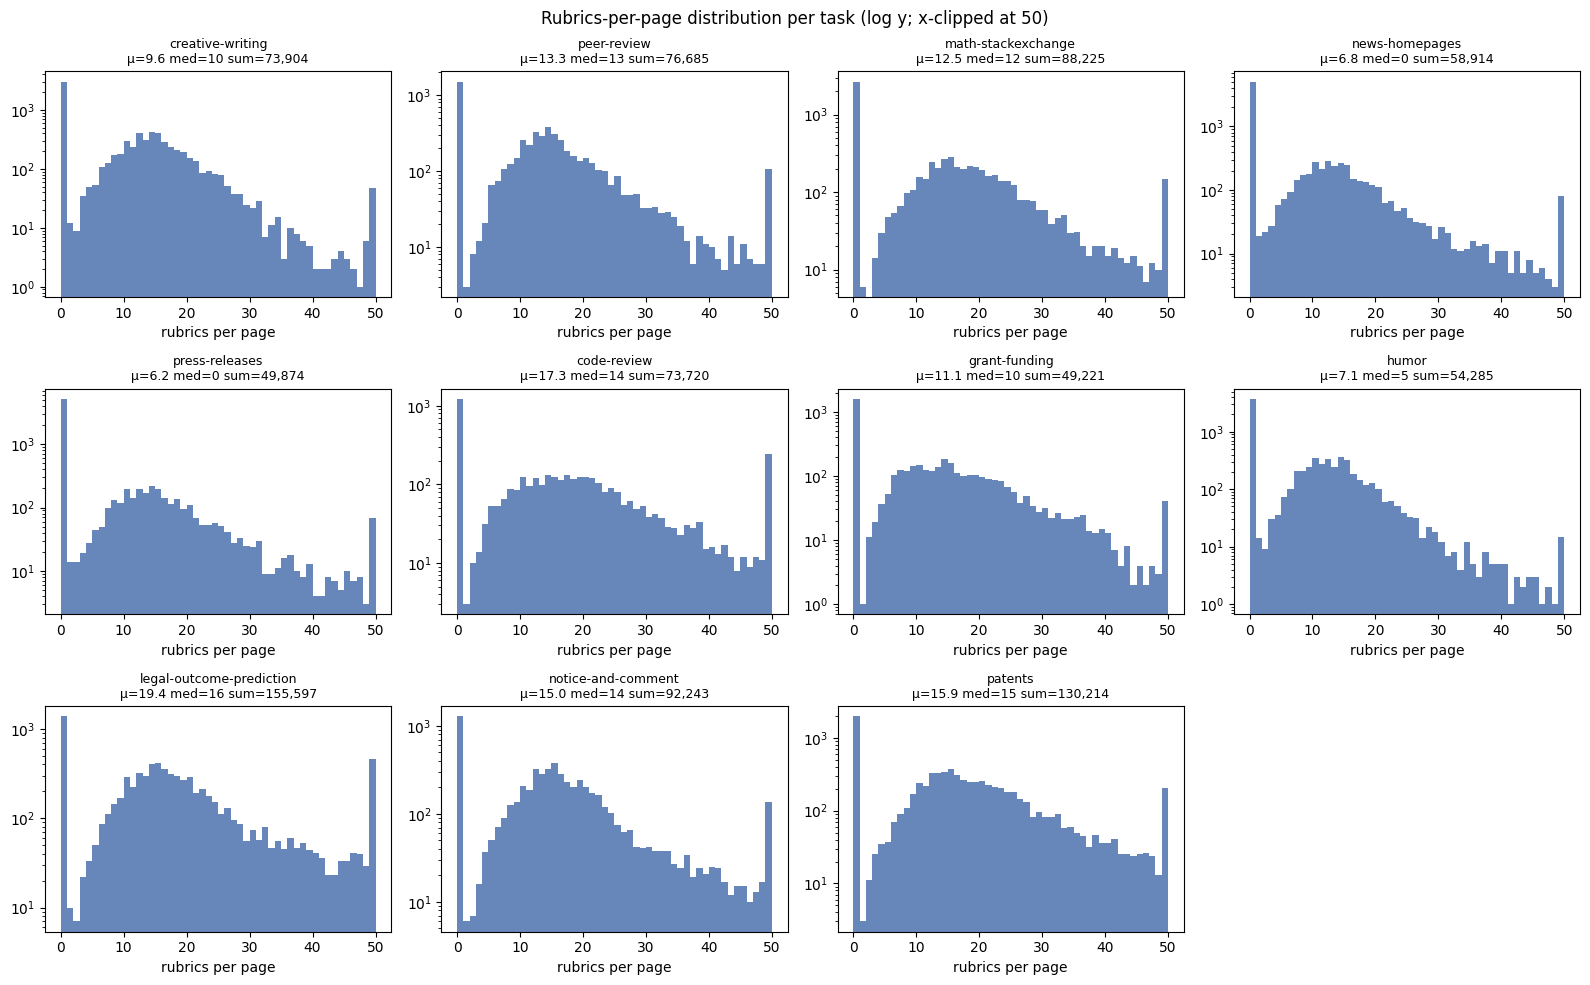

In [554]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=False)
for ax, task in zip(axes.flat, TASKS):
    s = pages_df.loc[pages_df.task == task, "n_rubrics"]
    ax.hist(s.clip(upper=50), bins=50, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{task}\nμ={s.mean():.1f} med={s.median():.0f} sum={s.sum():,}", fontsize=9)
    ax.set_xlabel("rubrics per page")
    ax.set_yscale("log")
for ax in axes.flat[len(TASKS):]:
    ax.set_visible(False)
fig.suptitle("Rubrics-per-page distribution per task (log y; x-clipped at 50)")
plt.tight_layout()
plt.show()

## 5. Orientation & breadth breakdown per task

In [555]:
orient_ct = pd.crosstab(pages_df.task, pages_df.orientation).fillna(0).astype(int)
print("Orientation × task:")
orient_ct

Orientation × task:


orientation,academic_page,blog_post,contest_criteria,course_syllabus,dataset,error,formal_guideline,forum_post,how_to,news_article,other,professional_standard,research_article,stylebook,textbook_excerpt,tutorial,wiki
task,,,,,,,,,,,,,,,,,
code-review,58,180,0,5,4,888,539,14,406,19,298,380,291,414,516,80,174
creative-writing,382,347,92,38,153,1303,250,12,1086,33,1802,239,123,86,1199,4,547
grant-funding,164,183,17,2,178,1070,1301,33,235,167,445,237,193,1,129,4,59
humor,278,351,28,25,25,1607,70,4,402,632,1386,59,219,19,721,35,1614
legal-outcome-prediction,227,146,16,14,26,1075,2785,13,229,45,329,876,141,66,1778,8,255
math-stackexchange,462,213,34,37,10,1914,418,6,350,94,434,124,593,100,1962,93,203
news-homepages,267,173,44,1,22,1279,134,0,182,3583,684,448,253,92,633,1,892
notice-and-comment,219,72,1,1,122,843,2643,0,124,94,461,458,241,3,682,0,162
patents,36,127,0,3,202,1636,2181,9,128,41,238,2871,262,1,371,13,52


In [556]:
c = orient_ct.drop(columns=['error']).mean().sort_values().index

Text(0.5, 1.0, 'Where are these metrics coming from?')

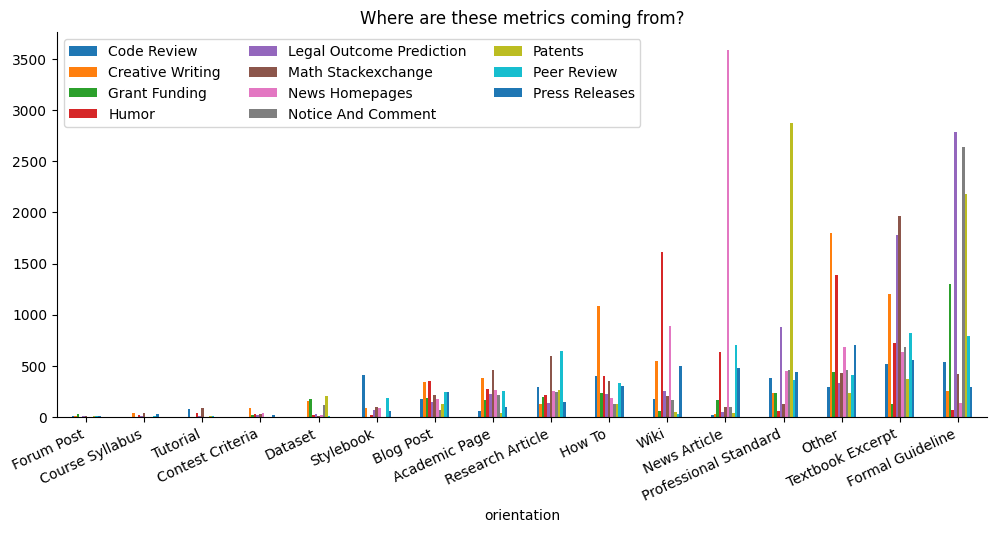

In [557]:
ax = orient_ct.drop(columns=['error'])[c].rename(
    index=lambda x: x.replace('-', ' ').title(),
    columns=lambda x: x.replace('_', ' ').title()
).T.plot(kind='bar', figsize=(12,5))
plt.xticks(rotation=25, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(ncols=3)
plt.title('Where are these metrics coming from?')

In [558]:
breadth_ct = pd.crosstab(pages_df.task, pages_df.subtask_breadth).fillna(0).astype(int)
# Order breadth columns sensibly
breadth_order = ["very_narrow", "narrow", "moderate", "broad", "very_broad", ""]
present_cols = [c for c in breadth_order if c in breadth_ct.columns] + [
    c for c in breadth_ct.columns if c not in breadth_order
]
breadth_ct = breadth_ct[present_cols]
print("\nSubtask breadth × task:")
breadth_ct


Subtask breadth × task:


subtask_breadth,very_narrow,narrow,moderate,broad,very_broad
task,,,,,
code-review,748,2117,482,827,29
creative-writing,1331,3963,1151,1127,82
grant-funding,1159,2257,318,556,59
humor,1734,4357,717,486,59
legal-outcome-prediction,994,4665,1005,1275,79
math-stackexchange,2011,3060,1281,617,37
news-homepages,1289,4949,1145,1194,67
notice-and-comment,787,3436,532,1294,68
patents,1467,4912,659,1003,64


## 6. Subtask vocabulary — what are the page-level subtasks?

`subtask_short` is the per-page subtask label. Top values per task hint at how diverse the subtask space is.

In [559]:
for task in TASKS:
    sub = pages_df[(pages_df.task == task) & (~pages_df.is_error)]
    counts = sub.subtask_short.fillna("").value_counts().head(15)
    print(f"\n=== {task}  (n={len(sub):,} non-error pages, {sub.subtask_short.nunique():,} distinct subtasks) ===")
    print(counts.to_string())


=== creative-writing  (n=6,395 non-error pages, 5,299 distinct subtasks) ===
subtask_short
reading literary short fiction           68
writing tragic drama                     42
reading short fiction                    37
country_profile_factbook_entry           20
writing historical narrative             19
short_story_excerpt                      16
country_profile_reference                16
country_profile_factbook                 16
writing tragedy and epic poetry          15
reading Victorian novel excerpt          13
writing short stories                    13
writing epic and tragic poetry           12
distributing Project Gutenberg eBooks    11
reading 19th-century novel excerpt       10
reading literary fiction excerpt         10

=== peer-review  (n=4,846 non-error pages, 4,316 distinct subtasks) ===
subtask_short
popular_science_magazine_article          30
evaluating inductive reasoning            10
evaluating_inductive_reasoning            10
evaluating_scientific_book

## 7. Top keywords per task

Aggregate `subtask_keywords` over all non-error pages, per task.

In [560]:
from collections import Counter

for task in TASKS:
    sub = pages_df[(pages_df.task == task) & (~pages_df.is_error)]
    c = Counter()
    for kws in sub.subtask_keywords:
        c.update([k.lower() for k in (kws or [])])
    print(f"\n=== {task}  (top 25 subtask_keywords) ===")
    for k, v in c.most_common(25):
        print(f"  {v:>5d}  {k}")


=== creative-writing  (top 25 subtask_keywords) ===
   1133  creative_writing
    784  fiction
    624  poetry
    594  literary_criticism
    493  short_story
    418  19th_century
    362  novel
    315  early_20th_century
    259  poetics
    239  tragedy
    224  characterization
    205  18th_century
    191  prose
    190  literary_fiction
    185  drama
    177  style
    165  short_fiction
    142  aesthetics
    133  novel_excerpt
    130  point_of_view
    129  translation
    128  essay
    127  dialogue
    124  architecture
    122  narrative

=== peer-review  (top 25 subtask_keywords) ===
   1188  peer_review
    312  popular_science
    267  philosophy_of_science
    260  19th_century
    256  induction
    246  natural_history
    239  scientific_method
    187  natural_philosophy
    181  philosophy
    159  book_review
    155  logic
    134  research_integrity
    124  systematic_review
    123  machine_learning
    121  open_peer_review
    110  evolution
    106  

## 11. Pages tagged 'error' — quick QA

What's actually in the error pages? (Captcha, 404, empty, paywall…)

In [561]:
err = pages_df[pages_df.is_error]
print(f"\nError pages by task:")
print(err.task.value_counts())
print(f"\nError-reason samples:")
print(err.error.value_counts().head(25))


Error pages by task:
task
press-releases              4185
math-stackexchange          1914
patents                     1636
humor                       1607
creative-writing            1303
news-homepages              1279
legal-outcome-prediction    1075
grant-funding               1070
peer-review                  917
code-review                  888
notice-and-comment           843
Name: count, dtype: int64

Error-reason samples:
error
Cloudflare anti-bot interstitial                                                    397
unreadable_source (html)                                                            228
unreadable_source (pdf)                                                             134
unreadable_source (empty)                                                           128
PDF extraction error: No /Root object                                               110
404 page not found                                                                   95
Cloudflare/anti-bot interst

## 12. Convenience: save a flat CSV for downstream tools

In [562]:
flat_csv = CACHE / "rubrics_flat.csv"
rubrics_df.drop(columns=["rubric_name_norm"], errors="ignore").to_csv(flat_csv, index=False)
print(f"wrote {flat_csv}  ({flat_csv.stat().st_size/1e6:.1f} MB)")

pages_csv = CACHE / "pages.csv"
pages_export = pages_df.copy()
pages_export["subtask_keywords"] = pages_export["subtask_keywords"].apply(json.dumps)
pages_export.to_csv(pages_csv, index=False)
print(f"wrote {pages_csv}  ({pages_csv.stat().st_size/1e6:.1f} MB)")

wrote /Users/spangher/Projects/stanford-research/norm-research/notebooks/_explore_cache/rubrics_flat.csv  (552.0 MB)
wrote /Users/spangher/Projects/stanford-research/norm-research/notebooks/_explore_cache/pages.csv  (47.2 MB)


## 13. Overall counts & specificity breakdown per task

Where every page ends up after the downstream pipeline runs:

```
pages  ─►  rubrics  ─►  canonical forms  ─►  L0 clusters  ─►  R1 families  ─►  R2 criteria  ─►  R3 themes
(this NB)             (canonicalize)        (locked tau)    (per-batch LLM)   (next)            (next)
```

The canonicalize step also assigns each form a **specificity bucket** —
`general` (cross-context), `specific` (this-document-particular), or
`hyper_specific` (very-narrow / one-shot). This bucket controls what
"same?" means downstream and explains a lot of the compression behavior.


In [563]:
# Load downstream structural-metric artifacts (already computed on sk3, mirrored locally).
from collections import Counter, defaultdict

ANALYSES = ROOT / "outputs" / "analyses"
SM = ANALYSES / "structural_metrics"
HIER = ROOT / "outputs" / "hierarchy"           # legacy R1-refined/R2/R3 artifacts
CANON = ANALYSES / "canon_all_real_forms.jsonl" # 53,413 canonical leaves

# (a) per-(task, bucket) canonical-form counts
bucket_counts = Counter()
with open(CANON) as f:
    for line in f:
        o = json.loads(line)
        bucket_counts[(o["task"], o["bucket"])] += 1

# (b) per-task L0 cluster counts come from concentration.json
concentration = json.loads((SM / "concentration.json").read_text())
specificity   = json.loads((SM / "specificity.json").read_text())
top_clusters  = json.loads((SM / "top_clusters.json").read_text())
consensus     = json.loads((SM / "consensus.json").read_text())

# (c) R1 family counts: only peer-review is built locally; others are pending
r1_counts = {}
for f in SM.glob("r1_families_*.json"):
    task = f.stem.replace("r1_families_", "")
    d = json.loads(f.read_text())
    r1_counts[task] = len(d.get("families", []))

# (d) legacy hierarchy (build_hierarchy/refine_parent/meta_merge) R2 and R3
#     are deprecated — see notes/2026-05-19__structural-metrics.md §7.
#     We still report them for orientation since R2/R3 in the new pipeline
#     are not built yet.
legacy_r2 = {}
legacy_r3 = {}
for task in TASKS:
    r2p = HIER / f"{task}_general_r2_expanded.json"
    r3p = HIER / f"{task}_general_r3_expanded.json"
    if r2p.exists():
        legacy_r2[task] = len(json.loads(r2p.read_text()).get("merged_groups", []))
    if r3p.exists():
        legacy_r3[task] = len(json.loads(r3p.read_text()).get("grandparents", []))

print(f"loaded structural metrics for {len(concentration)} tasks · "
      f"R1 (new pipeline) for {len(r1_counts)} task(s) · "
      f"legacy R2/R3 for {len(legacy_r2)} task(s)")


loaded structural metrics for 11 tasks · R1 (new pipeline) for 11 task(s) · legacy R2/R3 for 11 task(s)


### 13a. Overall counts per task — every level of the pipeline

One row per task. The leftmost columns are upstream (this notebook's frames);
the right columns walk down to the locked-clustering output and the in-progress
R1/R2/R3 levels.

- **L0** = "same rubric, restated" — locked clustering at tau 0.825.
- **R1** = "same underlying principle" — per-batch LLM grouping over L0
  clusters. Only `peer-review` is built; other tasks pending.
- **R2 (legacy)** / **R3 (legacy)** come from the deprecated
  `build_hierarchy / refine_parent / meta_merge` pipeline (general bucket only)
  and are shown only as rough order-of-magnitude orientation for the targets
  the new pipeline is aiming for (~12–15K R1, ~1.5–3K R2, ~200–300 R3).


In [564]:
rows = []
for task in TASKS:
    n_pages    = int((pages_df.task == task).sum())
    n_pages_ok = int(((pages_df.task == task) & (~pages_df.is_error)).sum())
    n_rubrics  = int((rubrics_df.task == task).sum())
    n_canon    = sum(bucket_counts[(task, b)] for b in ("general", "specific", "hyper_specific"))
    n_l0       = concentration.get(task, {}).get("n_clusters")
    n_r1       = r1_counts.get(task)
    n_r2_leg   = legacy_r2.get(task)
    n_r3_leg   = legacy_r3.get(task)
    rows.append({
        "task": task,
        "pages": n_pages,
        "pages_ok": n_pages_ok,
        "rubrics": n_rubrics,
        "canon_forms": n_canon,
        "L0_clusters": n_l0,
        "R1 (new)": n_r1 if n_r1 is not None else "—",
        "R2 (legacy)": n_r2_leg if n_r2_leg is not None else "—",
        "R3 (legacy)": n_r3_leg if n_r3_leg is not None else "—",
    })
levels_df = pd.DataFrame(rows).set_index("task")

# total row
totals = {
    "pages":       int(levels_df["pages"].sum()),
    "pages_ok":    int(levels_df["pages_ok"].sum()),
    "rubrics":     int(levels_df["rubrics"].sum()),
    "canon_forms": int(levels_df["canon_forms"].sum()),
    "L0_clusters": int(sum(v for v in levels_df["L0_clusters"] if isinstance(v, (int, float)))),
    "R1 (new)":    sum(v for v in levels_df["R1 (new)"] if isinstance(v, (int, float))),
    "R2 (legacy)": sum(v for v in levels_df["R2 (legacy)"] if isinstance(v, (int, float))),
    "R3 (legacy)": sum(v for v in levels_df["R3 (legacy)"] if isinstance(v, (int, float))),
}
levels_df.loc["— TOTAL —"] = totals

styled = (
    levels_df.style
    .format({c: "{:,.0f}" for c in ["pages","pages_ok","rubrics","canon_forms","L0_clusters"]}, na_rep="—")
    .background_gradient(subset=["pages","rubrics","canon_forms","L0_clusters"],
                         cmap="Blues", axis=0)
    .set_caption("Per-task counts across the rubric pipeline (totals at bottom).")
)
display(styled)


,pages,pages_ok,rubrics,canon_forms,L0_clusters,R1 (new),R2 (legacy),R3 (legacy)
task,,,,,,,,
creative-writing,"7,698","6,395","73,904","4,950","2,941",1700,371,42
peer-review,"5,763","4,846","76,685","3,257","1,871",1093,88,18
math-stackexchange,"7,047","5,133","88,225","5,257","3,381",2048,141,22
news-homepages,"8,690","7,411","58,914","3,022","1,610",814,150,22
press-releases,"8,090","3,905","49,874","5,630","3,427",1776,221,23
code-review,"4,266","3,378","73,720","12,262","8,118",5236,133,23
grant-funding,"4,418","3,348","49,221","2,836","1,657",843,91,17
humor,"7,637","6,030","54,285","5,885","3,407",2045,285,38
legal-outcome-prediction,"8,032","6,957","155,597","3,303","2,268",1332,104,23


### 13b. Specificity-bucket breakdown per task

The canonicalize step splits each form into one of three buckets. `general`
forms are broad evaluation criteria that travel cross-context; `specific`
forms are document-particular ("the introduction should state the hypothesis
in one sentence"); `hyper_specific` are very-narrow / one-shot.

Compression behavior across buckets confirms the design: `general` compresses
1.5–1.9× because broad rubrics genuinely repeat across guides, while
`specific`/`hyper_specific` stay close to 1× because canonicalization was
explicitly told to preserve specificity.


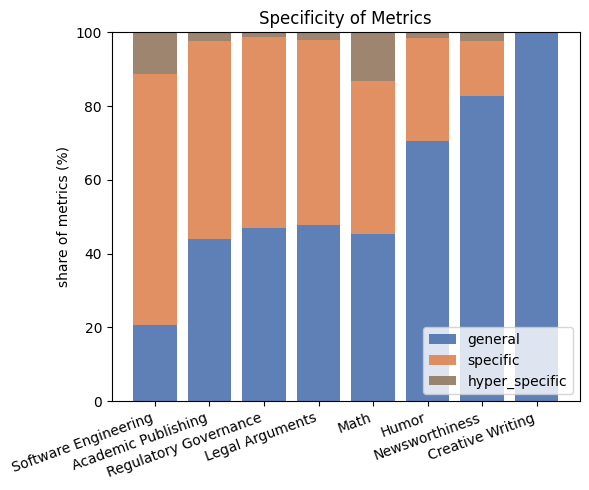

In [565]:
# Per-bucket counts + compression, using the specificity.json artifact when present.
BUCKETS = ["general", "specific", "hyper_specific"]

rows = []
for task in TASKS:
    spec = specificity.get(task, {})
    for b in BUCKETS:
        forms = bucket_counts[(task, b)]
        b_info = spec.get(b, {})
        clusters = b_info.get("n_clusters")
        pct_single = b_info.get("pct_singleton")
        compression = (forms / clusters) if clusters else None
        rows.append({
            "task": task, "bucket": b,
            "forms": forms,
            "clusters": clusters,
            "compression": compression,
            "pct_singleton": pct_single,
        })
bucket_df = pd.DataFrame(rows)

# Normalized stacked: percent share by bucket
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
piv = bucket_df.pivot(index="task", columns="bucket", values="forms").reindex(columns=BUCKETS).fillna(0)
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]
colors = {"general":"#4C72B0", "specific":"#DD8452", "hyper_specific":"#937860"}

ax = axes
pct = (
    (piv.div(piv.sum(axis=1), axis=0) * 100)
        .sort_values('specific', ascending=False)
        .rename(index=lambda x: x.replace('-', ' ').title())
           .rename(mapper={
                  'News Homepages': 'Newsworthiness',
                  'Math Stackexchange': 'Math', 
                  'Legal Outcome Prediction': 'Legal Arguments',
                  'Notice And Comment': 'Regulatory Governance',
                  'Peer Review': 'Academic Publishing',
                  'Code Review': 'Software Engineering'
              })
            .drop(['Press Releases', 'Grant Funding', 'Patents'])
)
bottom = np.zeros(len(pct))
for b in BUCKETS:
    ax.bar(pct.index, pct[b], bottom=bottom, label=b, color=colors[b], alpha=0.9)
    bottom += pct[b].values
ax.set_ylabel("share of metrics (%)")
ax.set_ylim(0, 100)
ax.set_title("Specificity of Metrics")
ax.legend(loc='lower right')
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

# # Compression per bucket
# print("\nCompression (forms ÷ clusters) per task × bucket:")
# comp = bucket_df.pivot(index="task", columns="bucket", values="compression").reindex(columns=BUCKETS)
# comp_str = comp.applymap(lambda v: f"{v:.2f}×" if pd.notna(v) else "—")
# display(comp_str)

### 13c. What do "general" vs "specific" vs "hyper_specific" rubrics actually look like?

The §13b table tells us *how many* forms went into each bucket. Below are
**example canonical forms per bucket** so the labels are concrete. Sampled
from peer-review (the task NB2 zooms in on); the same `canon_all_real_forms.jsonl`
file has the same bucket assignments for every other task.


In [566]:
# Load canonical forms with their bucket assignments and show examples per bucket.
from html import escape as _h2
from IPython.display import HTML as _HTML2, display as _disp2

canon_by_task_bucket = defaultdict(list)
with open(CANON) as f:
    for line in f:
        o = json.loads(line)
        canon_by_task_bucket[(o["task"], o["bucket"])].append(o)

_BUCKET_META = {
    "general":        ("#2563eb", "broad criteria that travel across contexts"),
    "specific":       ("#d97706", "document-particular rules"),
    "hyper_specific": ("#7c3aed", "very-narrow / one-shot constraints"),
}

def _bucket_card(task, bucket, n_show=6, seed=20):
    color, blurb = _BUCKET_META[bucket]
    pool = canon_by_task_bucket.get((task, bucket), [])
    if not pool:
        return f"<div style='padding:8px;color:#94a3b8;'>(no {bucket} forms for {task})</div>"
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(pool), size=min(n_show, len(pool)), replace=False)
    items = []
    for i in picks:
        o = pool[i]
        src = o["key"].split("::", 3)[2] if o["key"].count("::") >= 3 else o["key"]
        items.append(
            f'<li style="margin:4px 0;padding:6px 9px;background:#f8fafc;'
            f'border-left:3px solid {color};border-radius:4px;font-size:12.5px;">'
            f'<span style="color:#1e293b;">{_h2(o["canonical"])}</span>'
            f'<br><span style="color:#94a3b8;font-family:monospace;font-size:10.5px;">{_h2(src)}</span>'
            f'</li>'
        )
    return f"""
    <div style="border:1px solid #cbd5e1;border-top:4px solid {color};
                border-radius:7px;padding:10px 12px;margin:6px;background:#fff;
                font-family:-apple-system,BlinkMacSystemFont,sans-serif;flex:1;
                box-shadow:0 1px 2px rgba(0,0,0,0.04);min-width:0;">
      <div style="font-weight:700;color:{color};font-size:13.5px;">
        {bucket} <span style="color:#94a3b8;font-weight:400;">· {len(pool):,} forms total</span>
      </div>
      <div style="color:#64748b;font-size:11.5px;margin-bottom:6px;">{blurb}</div>
      <ul style="list-style:none;padding-left:0;margin:0;">{''.join(items)}</ul>
    </div>
    """

# Side-by-side cards for peer-review
_disp2(_HTML2("<h3 style='color:#0f172a;margin:6px 0;'>Peer-review canonical forms — one card per bucket</h3>"))
cols = "".join(_bucket_card("peer-review", b) for b in ["general", "specific", "hyper_specific"])
_disp2(_HTML2(f'<div style="display:flex;gap:8px;align-items:stretch;">{cols}</div>'))

# Compact comparison for all tasks: 2 examples per task per bucket as a wide table
print("\nCompact view: 2 random forms per (task, bucket):")
rows = []
for task in TASKS:
    row = {"task": task}
    for b in ["general", "specific", "hyper_specific"]:
        pool = canon_by_task_bucket.get((task, b), [])
        if not pool:
            row[b] = "—"
            continue
        rng = np.random.default_rng(7)
        picks = rng.choice(len(pool), size=min(2, len(pool)), replace=False)
        row[b] = " ¦ ".join(pool[i]["canonical"][:90] for i in picks)
    rows.append(row)
sample_df = pd.DataFrame(rows).set_index("task")
with pd.option_context("display.max_colwidth", 220, "display.width", 240):
    display(sample_df)



Compact view: 2 random forms per (task, bucket):


,general,specific,hyper_specific
task,,,
creative-writing,"The work should demonstrate a thoughtful and respectful adaptation of contemporary themes ¦ The ending should provide insight or clarity into the story's themes, characters, or plot.",—,—
peer-review,The work should be written in clear and correct English. ¦ The work should include relevant and accurate citations.,The project's satellite files should be checked for presence and correctness. ¦ The analytic code should be openly available.,The work should properly apply statistical and evidence-synthesis methods and thresholds. ¦ The project should have a public development history of at least 6 months.
math-stackexchange,The post should use whitespace and layout effectively. ¦ Minimize the use of subscripts and manage them clearly.,Use LaTeX structural markups for formatting mathematical expressions. ¦ The argument should use elliptic-type estimates to identify hyperbolic pieces.,The maximum value of σ on DS should be 8 points. ¦ The proof should end with a notation such as Q.E.D. or a tombstone symbol.
news-homepages,The story should be told from a specific and relevant point of view or perspective. ¦ Public business should be conducted in an open and transparent manner.,"The story should use external data sources for contextual validation. ¦ The story should offer original content, perspective, or insight.","The story should have readability indices such as FRES, FKGL, and ARI within acceptable ra ¦ The story should be presented in a faster-paced format with high segment density to engage"
press-releases,The press release should have a lead or teaser paragraph that engages the reader. ¦ The release should account for the cultural and contextual scope and limitations of its au,The release should use consistent spelling according to Webster's rules. ¦ The press release should include a trademark or service mark notice and credit the owner.,The words 'Club' or 'Clubs' should be capitalized when used. ¦ The dateline should be properly formatted.
code-review,Commit messages should communicate context. ¦ Method names should be short.,The design should allow for interactive prototyping without the need for writing code. ¦ Convert input data to the expected type and check that it is within the valid range and co,Escape sequences should be normalized to ensure consistent handling. ¦ Use UNIX-style LF line endings in code files.
grant-funding,"The proposed work should have effective project management. ¦ The proposal documents should be formatted to make them easy to scan and understand, using","The proposal should appropriately account for indirect costs. ¦ The proposal should include specific, high-quality training activities.",The proposal should include a realistic budget that takes into account the Cornell indirec ¦ The proposed work should have a time-bound duration.
humor,The humor should involve setting up an expectation for success and then subverting it with ¦ The caption should be quotable and reusable.,"The humor should effectively integrate dance and hip-hop elements, such as updating tradit ¦ The punchline should block strong assumptions and/or trigger weak ones.",The humor should use the fewest words necessary. ¦ The stand-up routine should be performed in a polished manner and last between 3 and 5 min
legal-outcome-prediction,The argument should avoid using passive voice in a way that conceals who performed an acti ¦ The argument should be specific rather than general.,The argument should identify safety and mobility performance measures in State policy. ¦ The argument should apply constructive interpretation through its three stages.,The exhibits should load and display quickly. ¦ Sentences should be under 25 words.


### 13d. L1 / L2 / L3 / L4 — the tractability ladder

Independent of the general/specific axis, the v7 two-axis classifier labels
every L0 cluster on a **tractability** (or *articulability*) ladder
describing **who can reliably verify it**:

- **L1 — verifiable / programmatic check**: a deterministic rule can decide.
  *e.g. "comment within filing period (timestamp)"; "code passes the unit test"*
- **L2 — LLM-judgeable**: a competent LLM with a briefed rubric can decide
  reproducibly. *e.g. "introduction states the hypothesis in one sentence"*
- **L3 — expert judgment**: requires domain expertise; LLMs diverge without
  operational definitions. *e.g. "is the legal argument substantive";
  "is the proof elegant"*
- **L4 — taste / intractable**: cannot be reliably checked even by experts;
  evaluation depends on irreducible aesthetic / subjective judgment.
  *e.g. "is this writing beautiful"; "will this resonate with readers"*

Two views below: **raw v7** (the direct classifier output) and **corrected**
(re-judges suspect L3 cases, since the raw run inflated L3 with some
LLM-judgeable items that the classifier mistakenly flagged as expert-only).
The corrected view is the better single estimate; the raw view is shown
side-by-side so the size of the correction is visible.


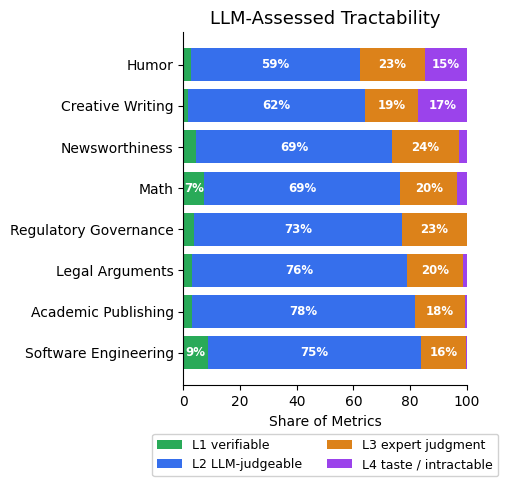

In [567]:
artic_raw  = pd.read_parquet(ANALYSES / "articulability_v7final_per_task.parquet").set_index("task")
artic_corr = pd.read_parquet(ANALYSES / "articulability_corrected_per_task.parquet").set_index("task")

L_LABELS = {
    "L1": ("L1 verifiable", "#16a34a"),
    "L2": ("L2 LLM-judgeable", "#2563eb"),
    "L3": ("L3 expert judgment", "#d97706"),
    "L4": ("L4 taste / intractable", "#9333ea"),
}
LS = ["L1", "L2", "L3", "L4"]

# Compose the corrected view (uses L2_corrected_pct and L3_corrected_pct)
corr = pd.DataFrame({
    "L1": artic_corr["L1_pct"],
    "L2": artic_corr["L2_corrected_pct"],
    "L3": artic_corr["L3_corrected_pct"],
    "L4": artic_corr["L4_pct"],
})
raw = pd.DataFrame({
    "L1": artic_raw["L1_pct"],
    "L2": artic_raw["L2_pct"],
    "L3": artic_raw["L3_pct"],
    "L4": artic_raw["L4_pct"],
})

# Order tasks by share of L3 + L4 (most expert/taste-heavy at top)
order = (corr["L3"] + corr["L4"]).sort_values(ascending=True).index.tolist()
corr_o = corr.loc[order]
raw_o  = raw.loc[order]

# Two side-by-side horizontal stacked-bar charts
fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharey=True)
for ax, df, title in [#(axes[0], raw_o, "Raw v7"), 
                      (axes, corr_o, "Corrected")]:
    df_copy = (df.rename(index=lambda x: x.replace('-', ' ').title())
           .rename(mapper={
                  'News Homepages': 'Newsworthiness',
                  'Math Stackexchange': 'Math', 
                  'Legal Outcome Prediction': 'Legal Arguments',
                  'Notice And Comment': 'Regulatory Governance',
                  'Peer Review': 'Academic Publishing',
                  'Code Review': 'Software Engineering'
              })
            .drop(['Press Releases', 'Grant Funding', 'Patents'])
            .copy()
        )
    left = np.zeros(len(df_copy))
    for L in LS:
        label, color = L_LABELS[L]
        ax.barh(df_copy.index,  df_copy[L], left=left, label=label, color=color, alpha=0.92)
        # annotate if segment is large enough to fit text
        for i, (val, l) in enumerate(zip(df_copy[L].values, left)):
            if val >= 6:
                ax.text(l + val/2, i, f"{val:.0f}%", ha="center", va="center",
                        color="white", fontsize=8.5, fontweight="bold")
        left += df_copy[L].values
    ax.set_xlim(0, 100)
    ax.set_xlabel("share of L0 clusters (%)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    
axes.legend(
    loc="upper center",      # Anchors the top of the legend box...
    bbox_to_anchor=(0.5, -0.12), # ...to the bottom center outside the axes
    fontsize=9, 
    framealpha=0.9, 
    ncols=2
)
plt.xlabel('Share of Metrics')
plt.title("LLM-Assessed Tractability", fontsize=13)
plt.tight_layout()
plt.show()

In [568]:
# # Compact tables: raw and corrected, side-by-side
# print("\nRaw v7 (% of L0 clusters per L per task):")
# display(
#     raw.style.format("{:.1f}%")
#        .background_gradient(subset=["L1"], cmap="Greens")
#        .background_gradient(subset=["L2"], cmap="Blues")
#        .background_gradient(subset=["L3"], cmap="Oranges")
#        .background_gradient(subset=["L4"], cmap="Purples")
# )

# print("\nCorrected (% of L0 clusters per L per task):")
# display(
#     corr.style.format("{:.1f}%")
#         .background_gradient(subset=["L1"], cmap="Greens")
#         .background_gradient(subset=["L2"], cmap="Blues")
#         .background_gradient(subset=["L3"], cmap="Oranges")
#         .background_gradient(subset=["L4"], cmap="Purples")
# )

# # Suspect-L3 magnitude (how much the correction changed things)
# print("\nSuspect-L3 reclassification per task (L3 cases the corrected pass moved to L2):")
# display(
#     artic_corr[["L3_raw_pct", "L3_corrected_pct", "suspect_l3_pct"]]
#         .rename(columns={"L3_raw_pct":"L3 raw %","L3_corrected_pct":"L3 corrected %",
#                           "suspect_l3_pct":"suspect-L3 moved to L2 %"})
#         .style.format("{:.1f}").background_gradient(subset=["suspect-L3 moved to L2 %"], cmap="Reds")
# )


### 13e. Example clusters per L — peer-review

Pulled from `cluster_2axis_l3_v7.jsonl` and `cluster_2axis_full_v7partial.jsonl`,
which hold per-cluster L assignments with a "why" rationale. A handful of
example peer-review clusters per tractability level so the rubric for each
L is concrete.


In [569]:
# Load per-cluster L assignments — concat both v7 files
pr_clusters_2axis = []
for fn in ["cluster_2axis_full_v7partial.jsonl", "cluster_2axis_l3_v7.jsonl"]:
    p = ANALYSES / fn
    if not p.exists():
        continue
    with open(p) as f:
        for line in f:
            try:
                o = json.loads(line)
            except json.JSONDecodeError:
                continue
            if o.get("task") == "peer-review" and isinstance(o.get("result"), dict):
                pr_clusters_2axis.append(o)
print(f"loaded {len(pr_clusters_2axis):,} peer-review clusters with v7 L-assignments")

# Bucket by L (articulability 1..4)
by_L = defaultdict(list)
for o in pr_clusters_2axis:
    L = int(o["result"].get("articulability", 0))
    if 1 <= L <= 4:
        by_L[L].append(o)
for L in [1,2,3,4]:
    print(f"  L{L}: {len(by_L[L]):>4} clusters")

# Render: card per L, with 3 example clusters showing medoid name + why
def _L_card(L, n_show=3, seed=11):
    label, color = L_LABELS[f"L{L}"]
    pool = by_L.get(L, [])
    if not pool:
        return f"<div style='padding:8px;color:#94a3b8;'>(no L{L} clusters available locally)</div>"
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(pool), size=min(n_show, len(pool)), replace=False)
    items = []
    for i in picks:
        o = pool[i]
        nm   = _h2(o.get("medoid_name", "")[:120] or "(no name)")
        desc = _h2(o.get("medoid_description", "")[:200])
        why  = _h2(o["result"].get("articulability_why", "")[:300])
        size = o.get("cluster_size", "?")
        items.append(
            f'<li style="margin:6px 0;padding:7px 10px;background:#f8fafc;'
            f'border-left:3px solid {color};border-radius:4px;font-size:12.5px;">'
            f'<div style="font-weight:600;color:#0f172a;">{nm}</div>'
            f'<div style="color:#334155;margin-top:3px;">{desc}</div>'
            f'<div style="color:#64748b;margin-top:4px;font-size:11.5px;font-style:italic;">'
            f'<b>why L{L}:</b> {why}</div>'
            f'<div style="color:#94a3b8;font-size:10.5px;margin-top:2px;">'
            f'cluster size: {size}</div>'
            f'</li>'
        )
    return f"""
    <div style="border:1px solid #cbd5e1;border-top:4px solid {color};
                border-radius:7px;padding:10px 12px;margin:6px;background:#fff;
                font-family:-apple-system,BlinkMacSystemFont,sans-serif;flex:1;
                box-shadow:0 1px 2px rgba(0,0,0,0.04);min-width:0;">
      <div style="font-weight:700;color:{color};font-size:13.5px;">
        {label} <span style="color:#94a3b8;font-weight:400;">· {len(pool):,} peer-review clusters</span>
      </div>
      <ul style="list-style:none;padding-left:0;margin:6px 0 0;">{''.join(items)}</ul>
    </div>
    """

_disp2(_HTML2("<h3 style='color:#0f172a;margin:6px 0;'>Peer-review clusters by tractability level (v7)</h3>"))
cols = "".join(_L_card(L) for L in [1,2,3,4])
_disp2(_HTML2(f'<div style="display:flex;gap:8px;align-items:stretch;flex-wrap:wrap;">{cols}</div>'))


loaded 439 peer-review clusters with v7 L-assignments
  L1:    1 clusters
  L2:  278 clusters
  L3:  156 clusters
  L4:    4 clusters


## 14. Concentration — is the rubric space a long tail or a few mega-concepts?

For each task, the locked clustering gives a per-cluster size distribution.
Normalized entropy near 1.0 = uniform / long-tail; Gini near 0 = uniform;
"top-10 coverage" = share of *forms* held by the largest 10 clusters.

**Headline finding (from `notes/2026-05-19__structural-metrics.md` §1):** the
rubric space is a long tail, not concentrated. Top-10 clusters cover only
3.5–12.5% of forms across all tasks — no task is dominated by a handful of
mega-concepts. `news-homepages` is the most concentrated; `notice-and-comment`
and `code-review` are the flattest.


,forms,clusters,%singleton,compression,entropy_norm,gini,top10 cov %,largest
task,,,,,,,,
news-homepages,3022,1610,74.800000,1.88×,0.92,0.42,12.500000,96
patents,4130,2397,76.300000,1.72×,0.93,0.38,11.600000,110
grant-funding,2836,1657,79.100000,1.71×,0.93,0.38,10.200000,44
peer-review,3257,1871,75.700000,1.74×,0.94,0.38,7.600000,31
legal-outcome-prediction,3303,2268,81.500000,1.46×,0.96,0.28,7.500000,97
humor,5885,3407,74.700000,1.73×,0.95,0.37,6.500000,114
notice-and-comment,2881,2046,83.700000,1.41×,0.96,0.27,6.200000,23
press-releases,5630,3427,77.100000,1.64×,0.95,0.35,6.200000,51
creative-writing,4950,2941,74.100000,1.68×,0.95,0.35,5.400000,42


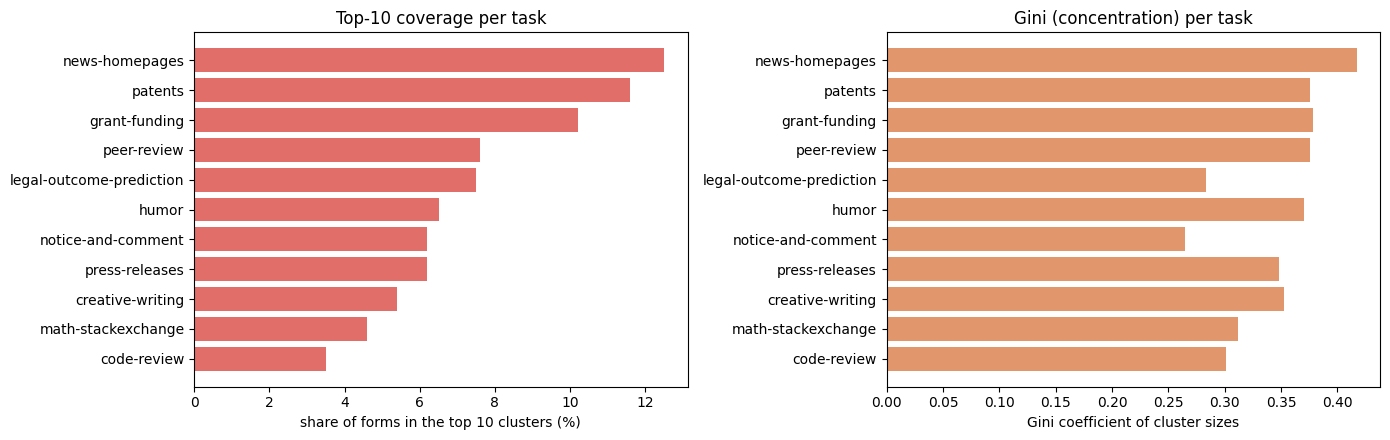

In [570]:
conc_rows = []
for task, d in concentration.items():
    conc_rows.append({
        "task": task,
        "forms":       d["n_forms"],
        "clusters":    d["n_clusters"],
        "%singleton":  round(d["pct_singleton"] * 100, 1),
        "compression": d["compression"],
        "entropy_norm":d["entropy_norm"],
        "gini":        d["gini"],
        "top10 cov %": round(d["top10"] * 100, 1),
        "largest":     d["largest"],
    })
conc_df = pd.DataFrame(conc_rows).set_index("task").sort_values("top10 cov %", ascending=False)
display(
    conc_df.style
    .format({"entropy_norm":"{:.2f}", "gini":"{:.2f}", "compression":"{:.2f}×"})
    .background_gradient(subset=["top10 cov %"], cmap="Reds")
    .background_gradient(subset=["gini"], cmap="Oranges")
    .background_gradient(subset=["entropy_norm"], cmap="Greens")
    .set_caption("Concentration metrics per task — sorted by top-10 coverage.")
)

# Two-panel chart: top-10 coverage and Gini per task
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order = conc_df.index.tolist()
axes[0].barh(order[::-1], conc_df["top10 cov %"].values[::-1], color="#DD5550", alpha=0.85)
axes[0].set_xlabel("share of forms in the top 10 clusters (%)")
axes[0].set_title("Top-10 coverage per task")
axes[1].barh(order[::-1], conc_df["gini"].values[::-1], color="#DD8452", alpha=0.85)
axes[1].set_xlabel("Gini coefficient of cluster sizes")
axes[1].set_title("Gini (concentration) per task")
plt.tight_layout()
plt.show()


## 19. R2 attribute taxonomy — what kind of rule is each aspect, and what is it about?

Two complementary views of the 3,816 R2 evaluation aspects across 11 tasks:

- **§19a — Subject taxonomy** (the headline): each aspect labeled with one of
  eight content categories (reasoning/methodology/originality/transparency/
  communication/aesthetic/format/safety). Answers *what does the rule
  measure?* Designed with bucket sizes that empirically spread (no single
  bucket >27% globally).
- **§19b — Meta-attribute profile**: each aspect labeled on three
  task-agnostic meta-axes (abstractness 1-5, stringency, reference frame).
  Answers *what shape does the rule have?*

(An earlier closed 5-axis pass — `rule_type` / `focus` / `outcome_vs_compliance`
/ `scope` / `modality` — was too skewed to be informative; its parquet is
kept at `outputs/r2_attr_labeling/agg/r2_attributes.parquet` and is loaded
silently for §19c-d's stability analyses, but its per-axis heatmaps are
not shown.)

§19c-f then layer time onto these — which subjects persist longest, which
are the newest entrants, and how each task's evaluation history reads.


### 19a. Subject taxonomy — what are the rules about?

A single-LLM-pass labeling (16 Sonnet subagents, ~3 min wall clock) classified
each of 3,816 R2 aspects into **one of eight content buckets**:

| Bucket | What it measures |
|---|---|
| **reasoning_evidence** | argument logic, claim-evidence match, statistical soundness |
| **methodology_process** | how the artifact was produced — design, testing, workflow |
| **originality_attribution** | novelty, contribution articulation, citation hygiene |
| **transparency_disclosure** | sharing data/methods/code/COI/AI use |
| **communication_audience** | clarity, accessibility, reader actionability |
| **aesthetic_craft** | voice, hook, elegance, punchline, narrative tension |
| **format_standards** | typography, named external standards (PEP 8, Bluebook, MPEP, CONSORT) |
| **safety_ethics** | harm avoidance, IRB, fairness, privacy, no misinformation |

The boundary rules (where the labeling instructions resolve ambiguous cases —
"comply with CONSORT" → format_standards; "avoid plagiarism" → originality;
"IRB approval" → safety_ethics) are in
`/tmp/subject_taxonomy_instructions_v1.md` and the per-task labels at
`outputs/r2_attr_labeling/agg/r2_subject_v3.parquet`.

The per-task signature heatmap below is the section's headline view.


3,816 aspects labeled across 11 tasks


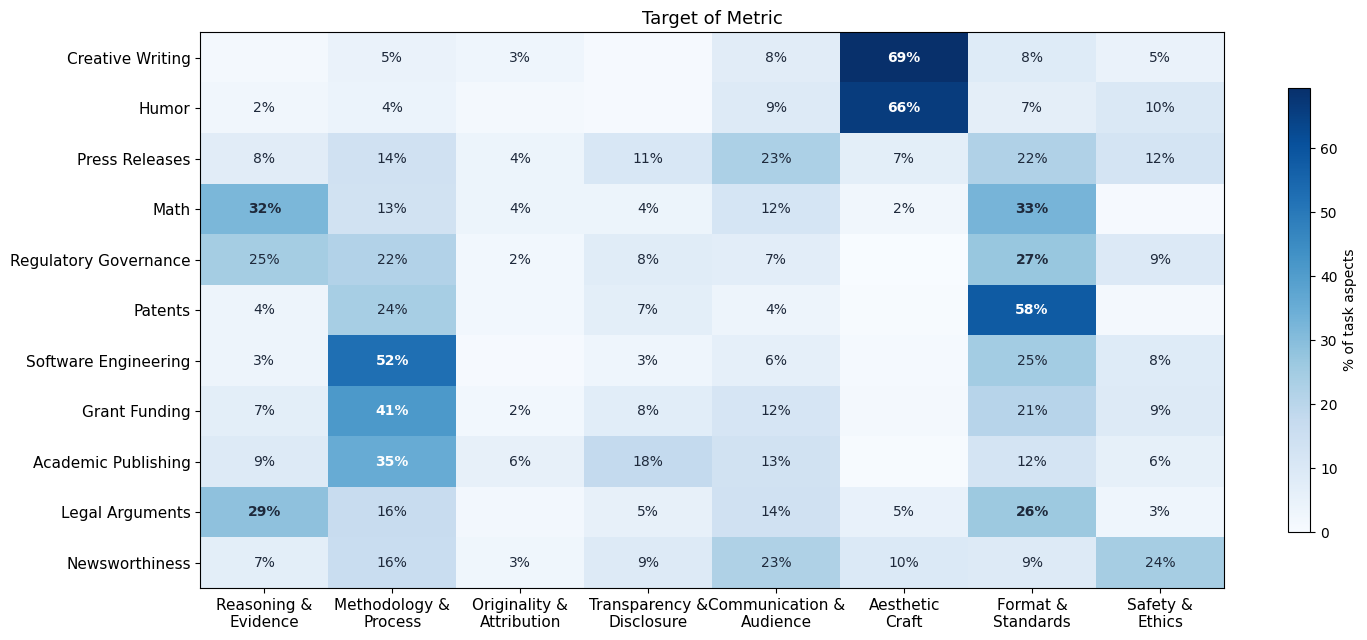


=== Overall subject distribution (global marginal) ===
  reasoning_evidence            10.7%
  methodology_process           26.7%
  originality_attribution        2.1%
  transparency_disclosure        5.5%
  communication_audience        10.3%
  aesthetic_craft               13.7%
  format_standards              23.1%
  safety_ethics                  7.8%


In [571]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

AGG = Path('/Users/spangher/Projects/stanford-research/norm-research/outputs/r2_attr_labeling/agg')
subj = pd.read_parquet(AGG / 'r2_subject_v3.parquet')
print(f'{len(subj):,} aspects labeled across {subj.task.nunique()} tasks')

SUBJ_ORDER = ['reasoning_evidence', 'methodology_process', 'originality_attribution',
              'transparency_disclosure', 'communication_audience', 'aesthetic_craft',
              'format_standards', 'safety_ethics']
SUBJ_SHORT = ['Reasoning &\nEvidence', 'Methodology &\nProcess',
              'Originality &\nAttribution', 'Transparency &\nDisclosure',
              'Communication &\nAudience', 'Aesthetic\nCraft',
              'Format &\nStandards', 'Safety &\nEthics']

# Per-task share, rows = tasks, cols = subjects
share = (subj.groupby(['task','subject']).size().unstack(fill_value=0)
              .reindex(columns=SUBJ_ORDER, fill_value=0))
share_pct = share.div(share.sum(axis=1), axis=0) * 100

# Order tasks by dominant subject for readability
task_order = share_pct.idxmax(axis=1).sort_values().index.tolist()
share_pct = share_pct.loc[task_order]

share_pct = (
    share_pct
 .rename(index=lambda x: x.replace('-', ' ').title())
 .rename(mapper={
                  'News Homepages': 'Newsworthiness',
                  'Math Stackexchange': 'Math', 
                  'Legal Outcome Prediction': 'Legal Arguments',
                  'Notice And Comment': 'Regulatory Governance',
                  'Peer Review': 'Academic Publishing',
                  'Code Review': 'Software Engineering'
              })
 # .drop(['Press Releases', 'Grant Funding', 'Patents'])
)

fig, ax = plt.subplots(figsize=(15, 6.5))
M = share_pct.values
im = ax.imshow(M, cmap='Blues', aspect='auto', vmin=0, vmax=min(70, M.max()))
ax.set_xticks(range(len(SUBJ_ORDER)))
ax.set_xticklabels(SUBJ_SHORT, fontsize=11)
ax.set_yticks(range(len(share_pct)))
ax.set_yticklabels(share_pct.index, fontsize=11)
for i in range(len(share_pct.index)):
    for j in range(len(SUBJ_ORDER)):
        v = M[i, j]
        if v >= 2:
            color = 'white' if v >= 35 else '#1e293b'
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=10,
                    color=color, fontweight='bold' if v >= 25 else 'normal')
ax.set_title('Target of Metric', fontsize=13)
fig.colorbar(im, ax=ax, shrink=0.8, label='% of task aspects')
plt.tight_layout(); plt.show()

# Compact overall marginal
print('\n=== Overall subject distribution (global marginal) ===')
m = subj.subject.value_counts(normalize=True).reindex(SUBJ_ORDER) * 100
for s, p in m.items():
    print(f'  {s:28s} {p:5.1f}%')


In [572]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

R2A = Path('/Users/spangher/Projects/stanford-research/norm-research/outputs/r2_attr_labeling/agg')
attr = pd.read_parquet(R2A / 'r2_attributes.parquet')
time_prof = pd.read_parquet(R2A / 'r2_time_profile.parquet')
join = pd.read_parquet(R2A / 'attr_time_join.parquet')
stability = pd.read_parquet(R2A / 'task_stability.parquet')

print(f'R2 attribute rows: {len(attr):,}')
print(f'time-profile rows: {len(time_prof):,}')
print(f'attr × time joined: {len(join):,}  (with year: {join["median_y"].notna().sum():,})')

R2 attribute rows: 19,838
time-profile rows: 3,816
attr × time joined: 19,838  (with year: 17,270)


### 19b. Meta-attribute profile (abstractness / stringency / reference frame)

Complementing §19a (the *what* of each rule), this section captures the *shape*:
three task-agnostic meta-axes labeled by the same parallel-subagent pass.

| Axis | Buckets | What it captures |
|---|---|---|
| **abstractness** | 1 (pure quality judgment) → 5 (operational rule with explicit threshold/token) | how concrete vs. abstract the rule is |
| **stringency** | must / should / may / avoid | modality of the rule |
| **reference_frame** | internal / external / aesthetic / utility | what standard grounds the judgment |

Three heatmaps below — tasks ordered by mean abstractness so each row reads
as a profile across all three meta-axes.


3,816 aspects labeled across 11 tasks (16 Sonnet subagents in parallel, ~3-4 min wall clock)


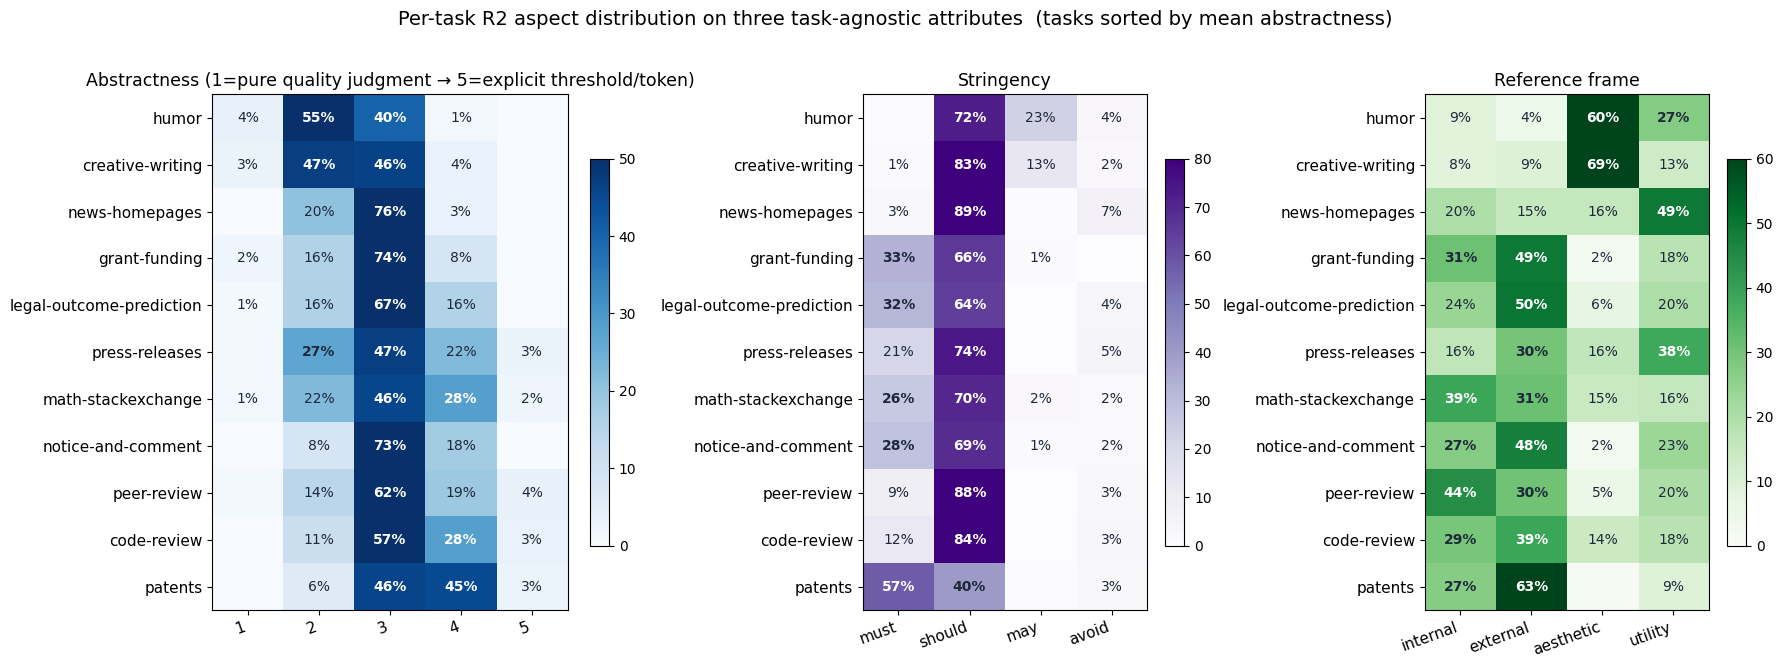


=== Per-task profile summary ===
                          mean_abstract  pct_must  pct_avoid  pct_aesthetic  pct_external  pct_utility  pct_internal
task                                                                                                                
humor                              2.39       1.0        4.0           60.0           4.0         27.0           9.0
creative-writing                   2.50       1.0        2.0           69.0           9.0         13.0           8.0
news-homepages                     2.83       3.0        7.0           16.0          15.0         49.0          20.0
grant-funding                      2.88      33.0        0.0            2.0          49.0         18.0          31.0
legal-outcome-prediction           2.98      32.0        4.0            6.0          50.0         20.0          24.0
press-releases                     3.00      21.0        5.0           16.0          30.0         38.0          16.0
math-stackexchange            

In [573]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

AGG = Path('/Users/spangher/Projects/stanford-research/norm-research/outputs/r2_attr_labeling/agg')
df = pd.read_parquet(AGG / 'r2_general_attrs_v2.parquet')
print(f'{len(df):,} aspects labeled across {df.task.nunique()} tasks '
      f'(16 Sonnet subagents in parallel, ~3-4 min wall clock)')

# Per-task ordering: ascending mean abstractness so concrete tasks at top
task_order = df.groupby('task').abstractness.mean().sort_values().index.tolist()

# ------- panel 1: abstractness (1-5) heatmap -------
abs_pct = (df.groupby(['task','abstractness']).size().unstack(fill_value=0))
abs_pct = abs_pct.reindex(columns=[1,2,3,4,5], fill_value=0)
abs_pct = abs_pct.div(abs_pct.sum(axis=1), axis=0) * 100
abs_pct = abs_pct.loc[task_order]

# ------- panel 2: stringency heatmap -------
STR_ORDER = ['must','should','may','avoid']
str_pct = (df.groupby(['task','stringency']).size().unstack(fill_value=0)
              .reindex(columns=STR_ORDER, fill_value=0))
str_pct = str_pct.div(str_pct.sum(axis=1), axis=0) * 100
str_pct = str_pct.loc[task_order]

# ------- panel 3: reference_frame heatmap -------
RF_ORDER = ['internal','external','aesthetic','utility']
rf_pct = (df.groupby(['task','reference_frame']).size().unstack(fill_value=0)
              .reindex(columns=RF_ORDER, fill_value=0))
rf_pct = rf_pct.div(rf_pct.sum(axis=1), axis=0) * 100
rf_pct = rf_pct.loc[task_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5),
                         gridspec_kw={'width_ratios': [5, 4, 4]})

panels = [
    ('Abstractness (1=pure quality judgment → 5=explicit threshold/token)',
     abs_pct, ['1','2','3','4','5'], 'Blues', 50),
    ('Stringency',
     str_pct, STR_ORDER, 'Purples', 80),
    ('Reference frame',
     rf_pct, RF_ORDER, 'Greens', 60),
]

for ax, (title, mat, cols, cmap, vmax) in zip(axes, panels):
    M = mat.values
    im = ax.imshow(M, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, fontsize=11, rotation=20, ha='right')
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=11)
    for i in range(len(mat.index)):
        for j in range(len(cols)):
            v = M[i, j]
            if v >= 1:
                color = 'white' if v >= vmax*0.55 else '#1e293b'
                ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                        fontsize=10, color=color,
                        fontweight='bold' if v >= 25 else 'normal')
    ax.set_title(title, fontsize=12.5)
    fig.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle('Per-task R2 aspect distribution on three task-agnostic attributes  '
             '(tasks sorted by mean abstractness)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Compact summary table
print('\n=== Per-task profile summary ===')
summ = pd.DataFrame({
    'mean_abstract': df.groupby('task').abstractness.mean().round(2),
    'pct_must': str_pct['must'].round(0),
    'pct_avoid': str_pct['avoid'].round(0),
    'pct_aesthetic': rf_pct['aesthetic'].round(0),
    'pct_external': rf_pct['external'].round(0),
    'pct_utility': rf_pct['utility'].round(0),
    'pct_internal': rf_pct['internal'].round(0),
}).loc[task_order]
print(summ.to_string())


### 19c. Task stability profile — which tasks have the most persistent norms?

For each R2 aspect we have a **source-year distribution** — the publication
years of every expert document that contributed to it. From this we compute
stability metrics per aspect, then roll up per task:

- **task_median_y** — the median of per-aspect median years. Lower = older / more traditional.
- **task_iqr_of_medians** — how spread out the per-aspect medians are. Lower = more uniform.
- **avg_aspect_halfdecades_touched** — how many 5-year buckets each aspect spans on average. Higher = longer continuous tradition.
- **pct_aspects_with_pre_2000_source** — what fraction of aspects have at least one ≤1999 source. Higher = field has historical roots.
- **pct_aspects_median_post_2020** — what fraction of aspects are dominantly recent.


,task,n_aspects_total,n_aspects_with_yr,task_median_y,task_iqr_of_medians,avg_aspect_halfdecades_touched,med_aspect_halfdecades_touched,pct_aspects_median_post_2020,pct_aspects_with_pre_2000_source,avg_aspect_iqr_y
5,math-stackexchange,403,364,2015.0,11.6,3.5,3.0,31.0,46.2,12.5
1,creative-writing,285,266,2018.0,9.8,4.2,4.0,38.7,56.4,17.1
3,humor,378,348,2018.5,7.0,3.7,3.0,42.2,39.9,10.0
4,legal-outcome-prediction,294,239,2018.5,10.0,2.9,2.0,40.2,34.7,13.0
6,news-homepages,231,201,2019.0,8.0,3.2,3.0,44.3,27.4,6.6
0,code-review,1059,880,2019.5,8.5,2.5,2.0,49.9,15.2,5.5
2,grant-funding,146,128,2019.8,6.6,3.0,3.0,50.0,24.2,5.0
7,notice-and-comment,296,237,2020.0,12.0,3.0,2.0,53.6,38.0,10.3
8,patents,257,232,2020.0,7.1,3.0,2.0,51.7,19.4,5.5
9,peer-review,218,196,2020.0,5.5,2.5,2.0,61.2,23.0,3.9


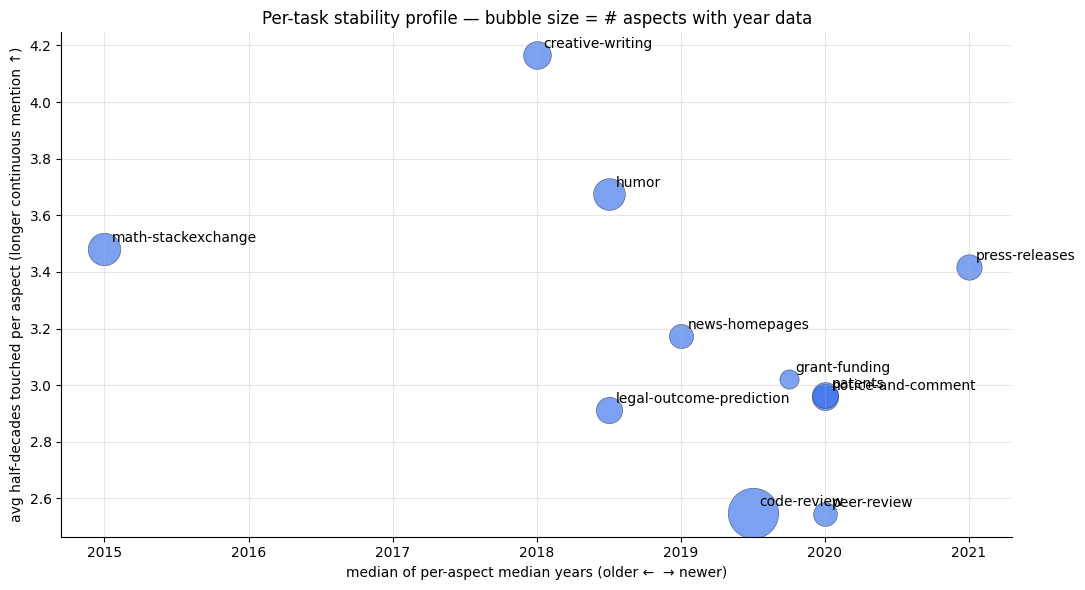

Reading:
  TOP-LEFT (old, long-spanning) = stable traditional norms: math, creative-writing
  BOTTOM-RIGHT (modern, narrow) = emerging fields: press-releases, peer-review


In [574]:
display(stability.round(1))

# Visualise: x = median year, y = avg half-decades touched
fig, ax = plt.subplots(figsize=(11, 6))
for _, r in stability.iterrows():
    ax.scatter(r['task_median_y'], r['avg_aspect_halfdecades_touched'],
               s=r['n_aspects_with_yr'] * 1.5, alpha=0.6, color='#2563eb',
               edgecolor='#1e293b', linewidth=0.5)
    ax.annotate(r['task'], (r['task_median_y'], r['avg_aspect_halfdecades_touched']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)
ax.set_xlabel('median of per-aspect median years (older ←  → newer)')
ax.set_ylabel('avg half-decades touched per aspect (longer continuous mention ↑)')
ax.set_title('Per-task stability profile — bubble size = # aspects with year data')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print('Reading:')
print('  TOP-LEFT (old, long-spanning) = stable traditional norms: math, creative-writing')
print('  BOTTOM-RIGHT (modern, narrow) = emerging fields: press-releases, peer-review')

### 19d. Most stable vs most emerging R2 aspects per task

Two extremes per task: (i) aspects that touch the most half-decade buckets
(longest continuous mention across time) and (ii) aspects whose sources are
all post-2020 (emerging / modern norms).


In [575]:
from html import escape as _h3
from IPython.display import HTML as _HTML3, display as _disp3

def render_aspect_row(r, kind):
    if kind == 'stable':
        color = '#0f766e'
        meta = f"{int(r['n_halfdecades_touched'])} half-decade buckets · {int(r['min_y'])}–{int(r['max_y'])} · n={int(r['n_sources_with_yr'])} sources"
    else:
        color = '#be185d'
        meta = f"median {int(r['median_y'])} · {int(r['min_y'])}–{int(r['max_y'])} · n={int(r['n_yrs'])} year hits"
    return (
        f'<li style="margin:4px 0;padding:6px 9px;background:#f8fafc;'
        f'border-left:3px solid {color};border-radius:4px;font-size:12.5px;">'
        f'<div style="font-weight:600;color:#0f172a;">{_h3(r["name"][:90])}</div>'
        f'<div style="color:#64748b;font-size:11px;">{meta}</div>'
        f'</li>'
    )

tp = time_prof[time_prof.n_yrs > 0].copy()
for task in stability.sort_values('task_median_y')['task']:
    sub = tp[tp.task == task]
    # stable: highest n_halfdecades_touched, requiring n_yrs >= 5
    stable = sub[sub.n_yrs >= 5].sort_values(
        ['n_halfdecades_touched', 'n_sources_with_yr'], ascending=False).head(5)
    # emerging: all sources >= 2020, n_yrs >= 3
    emerging = sub[(sub.pre_2000_share == 0) & (sub.median_y >= 2022) & (sub.n_yrs >= 3)].sort_values(
        'n_yrs', ascending=False).head(5)
    stable_html = ''.join(render_aspect_row(r, 'stable') for _, r in stable.iterrows())
    emerging_html = ''.join(render_aspect_row(r, 'emerging') for _, r in emerging.iterrows())
    if not stable_html and not emerging_html:
        continue
    html = f"""
    <div style="border:1px solid #cbd5e1;border-radius:7px;padding:10px 14px;margin:8px 0;
                background:#ffffff;font-family:-apple-system,BlinkMacSystemFont,sans-serif;
                box-shadow:0 1px 2px rgba(0,0,0,0.04);">
      <div style="font-size:15px;font-weight:700;color:#0f172a;margin-bottom:6px;">{_h3(task)}</div>
      <div style="display:flex;gap:10px;">
        <div style="flex:1;">
          <div style="font-size:12px;font-weight:700;color:#0f766e;margin-bottom:4px;">most stable (long continuous mention)</div>
          <ul style="list-style:none;padding-left:0;margin:0;">{stable_html or '<li style="color:#94a3b8;font-style:italic;font-size:12px;">none</li>'}</ul>
        </div>
        <div style="flex:1;">
          <div style="font-size:12px;font-weight:700;color:#be185d;margin-bottom:4px;">most emerging (all sources ≥ 2020)</div>
          <ul style="list-style:none;padding-left:0;margin:0;">{emerging_html or '<li style="color:#94a3b8;font-style:italic;font-size:12px;">none</li>'}</ul>
        </div>
      </div>
    </div>
    """
    _disp3(_HTML3(html))

### 19e. Subject × time cross-cut — which kinds of rules are old vs. new?

Joining the subject taxonomy (§19a) with the per-aspect source-year stats
(§19c) tells us **which subjects have the longest historical tails and which
are recent entrants** in the evaluation literature.

- The oldest subjects (most pre-2000 sources, earliest median year) are the
  "Aristotle" rules — reasoning and craft go back millennia.
- The newest are transparency and safety — data sharing, AI disclosure,
  algorithmic fairness norms are post-2020 inventions.


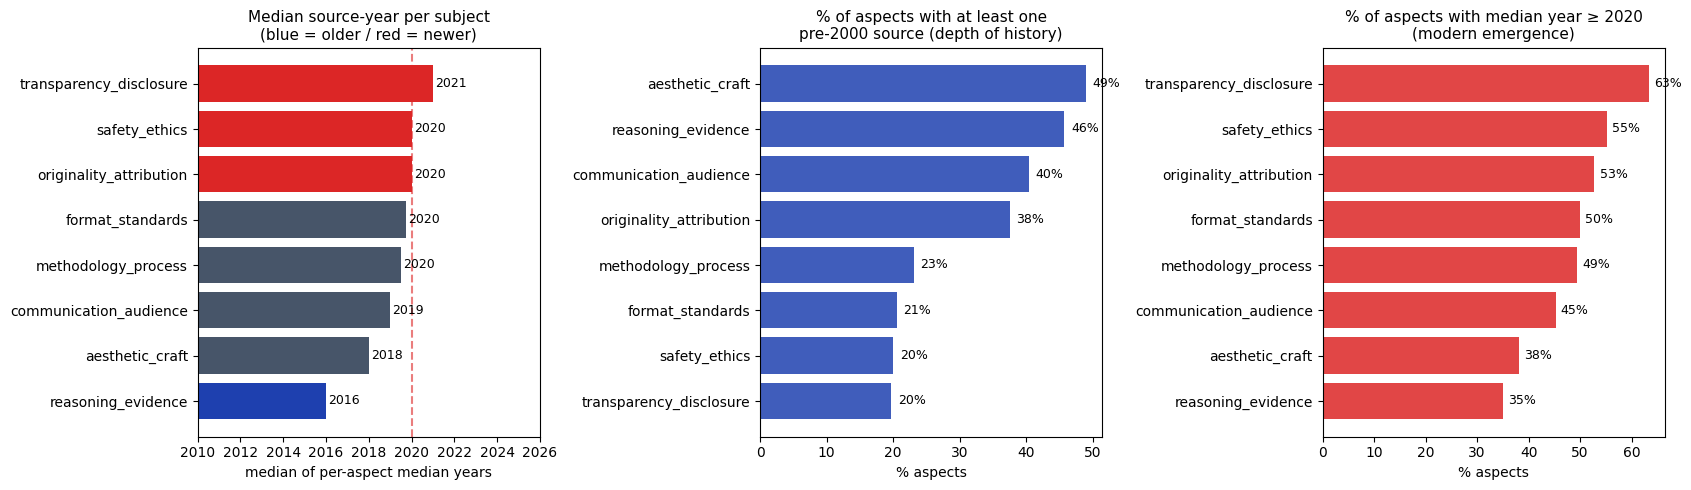


=== Per-subject time profile ===
                         n_aspect_rows  median_y_of_medians  avg_halfdecades_touched  pct_with_pre_2000_src  pct_median_post_2020
subject                                                                                                                          
reasoning_evidence                 359               2016.0                      3.2                   45.7                  35.1
methodology_process                863               2019.5                      2.7                   23.1                  49.4
originality_attribution             72               2020.0                      3.6                   37.5                  52.8
transparency_disclosure            188               2021.0                      2.7                   19.7                  63.3
communication_audience             347               2019.0                      3.8                   40.3                  45.2
aesthetic_craft                    484               201

In [576]:
subj_time = pd.read_csv(AGG / 'subject_x_median_year_v3.csv')
SUBJ_ORDER = ['reasoning_evidence', 'methodology_process', 'originality_attribution',
              'transparency_disclosure', 'communication_audience', 'aesthetic_craft',
              'format_standards', 'safety_ethics']
subj_time = subj_time.set_index('subject').loc[SUBJ_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel A: median-of-medians year per subject
ax = axes[0]
y = subj_time['median_y_of_medians'].sort_values()
colors = ['#1e40af' if v < 2018 else ('#dc2626' if v >= 2020 else '#475569') for v in y.values]
ax.barh(range(len(y)), y - 2010, color=colors, left=2010)
ax.set_yticks(range(len(y))); ax.set_yticklabels(y.index, fontsize=10)
ax.set_xlim(2010, 2026)
ax.axvline(2020, color='#dc2626', linestyle='--', alpha=0.6, label='2020')
ax.axvline(2000, color='#1e40af', linestyle='--', alpha=0.0)
for i, v in enumerate(y.values):
    ax.text(v + 0.1, i, f'{v:.0f}', va='center', fontsize=9)
ax.set_title('Median source-year per subject\n(blue = older / red = newer)', fontsize=11)
ax.set_xlabel('median of per-aspect median years')

# Panel B: % aspects with at least one pre-2000 source
ax = axes[1]
y2 = subj_time['pct_with_pre_2000_src'].sort_values()
ax.barh(range(len(y2)), y2.values, color='#1e40af', alpha=0.85)
ax.set_yticks(range(len(y2))); ax.set_yticklabels(y2.index, fontsize=10)
for i, v in enumerate(y2.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_title('% of aspects with at least one\npre-2000 source (depth of history)', fontsize=11)
ax.set_xlabel('% aspects')

# Panel C: % aspects with median year ≥ 2020 (modernity)
ax = axes[2]
y3 = subj_time['pct_median_post_2020'].sort_values()
ax.barh(range(len(y3)), y3.values, color='#dc2626', alpha=0.85)
ax.set_yticks(range(len(y3))); ax.set_yticklabels(y3.index, fontsize=10)
for i, v in enumerate(y3.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_title('% of aspects with median year ≥ 2020\n(modern emergence)', fontsize=11)
ax.set_xlabel('% aspects')

plt.tight_layout(); plt.show()

print('\n=== Per-subject time profile ===')
print(subj_time.round(1).to_string())


### 19f. Longest-running metrics per task — when did each norm enter the literature?

Per-task figure showing both:

- **Top section (task color)** — top 15 R2 aspects by source-year **span**:
  aspects whose earliest mention is oldest. These are the *perennial* norms
  of the field. Horizontal bars run from `min_y` → `max_y`; tick marks show
  individual sources; end-dots mark exact endpoints.
- **Bottom section (red, separated by a divider)** — top 5 aspects whose
  median source year is **post-2022** with ≥3 sources. These are the
  *emerging* / modern norms.

**Source annotations** — for the most striking ancient sources (named-author
texts identifiable from `subtask_short`), a labelled arrow points to the
earliest tick (e.g. "Kant (1790)" for humor, "Ivy Lee (1906)" for press
releases, "Lippmann (1922)" for news, etc.).

**How to read.** A long, evenly-shaded bar = a perennial norm cited
continuously across time. A long bar that's only saturated on the right =
the norm exists historically but was only formalised recently. A short red
bar on the right = a modern-only emerging norm.

Source: `outputs/r2_attr_labeling/agg/r2_aspect_year_mentions_distinct_sources.parquet`


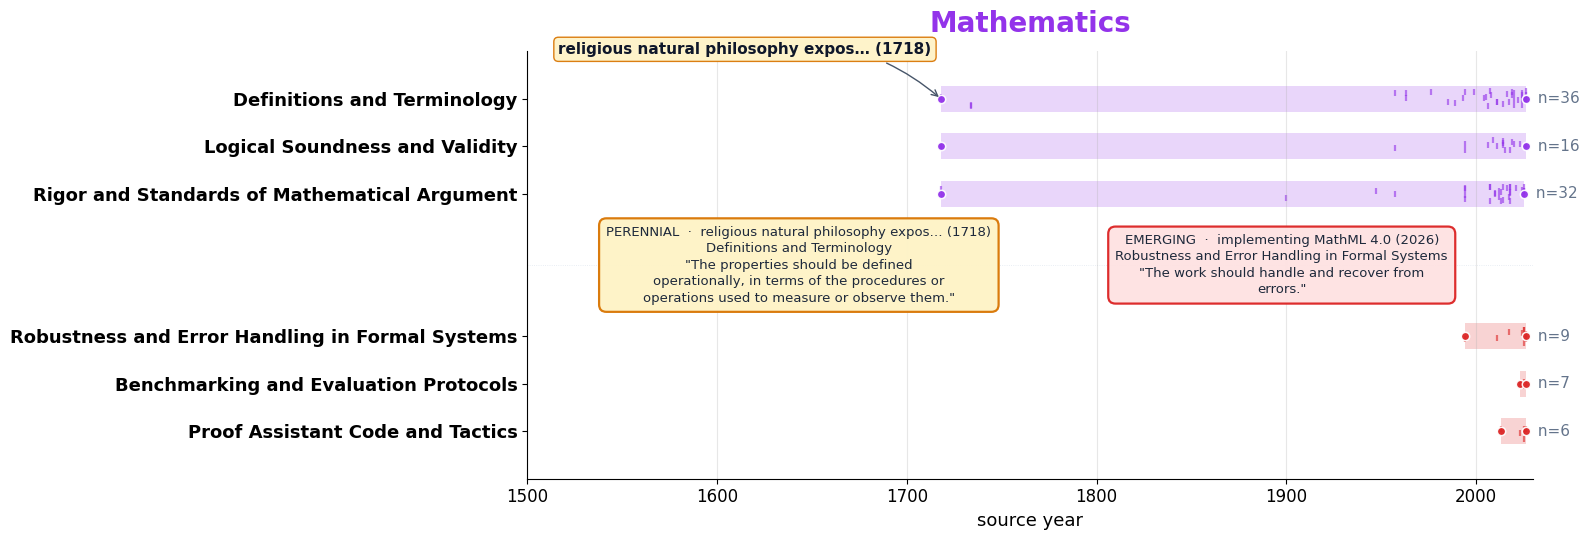

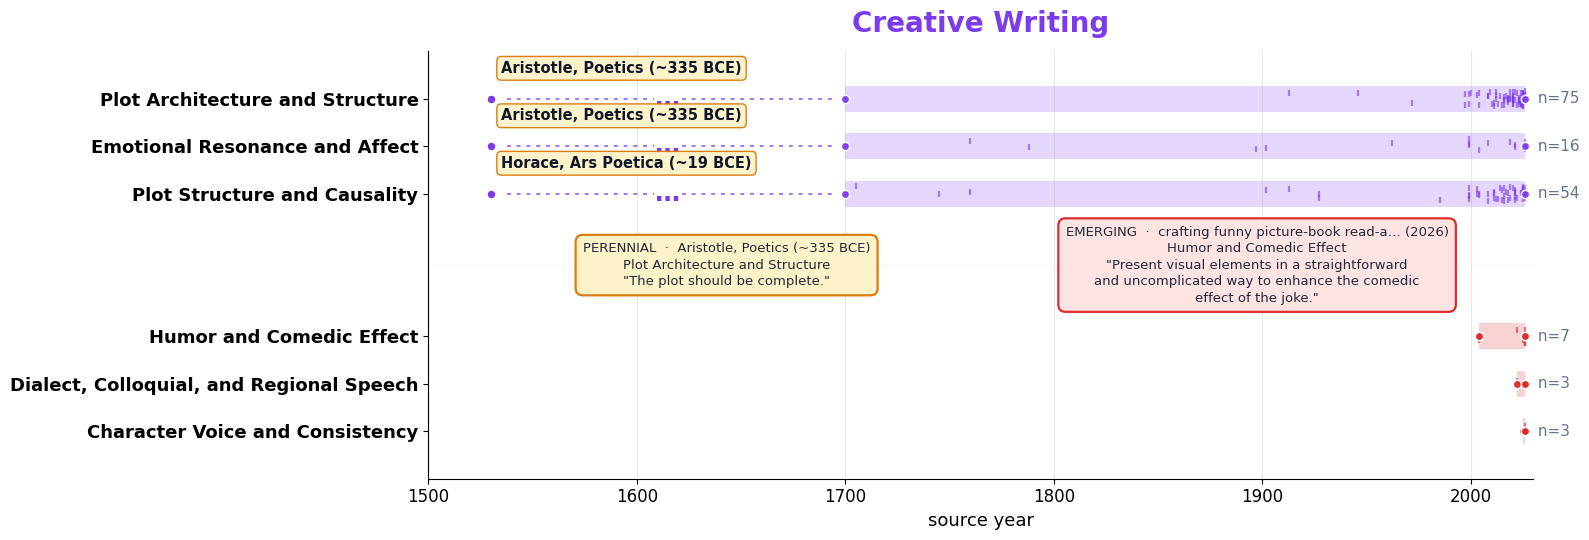

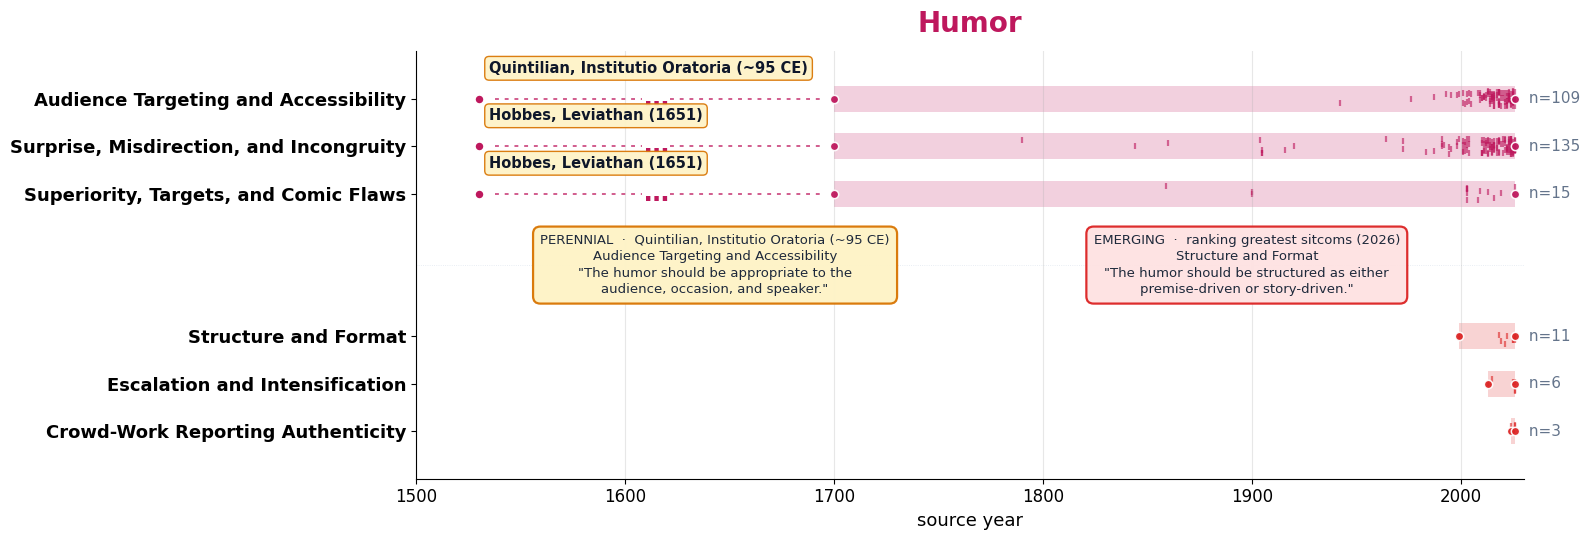

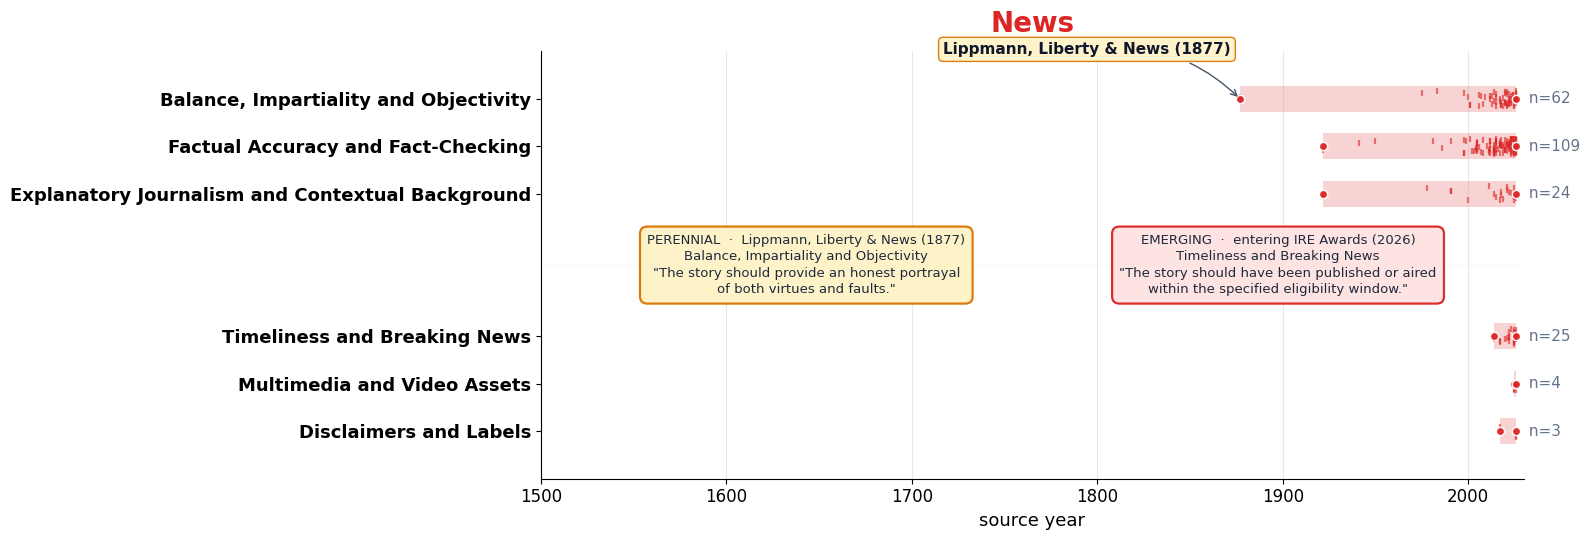

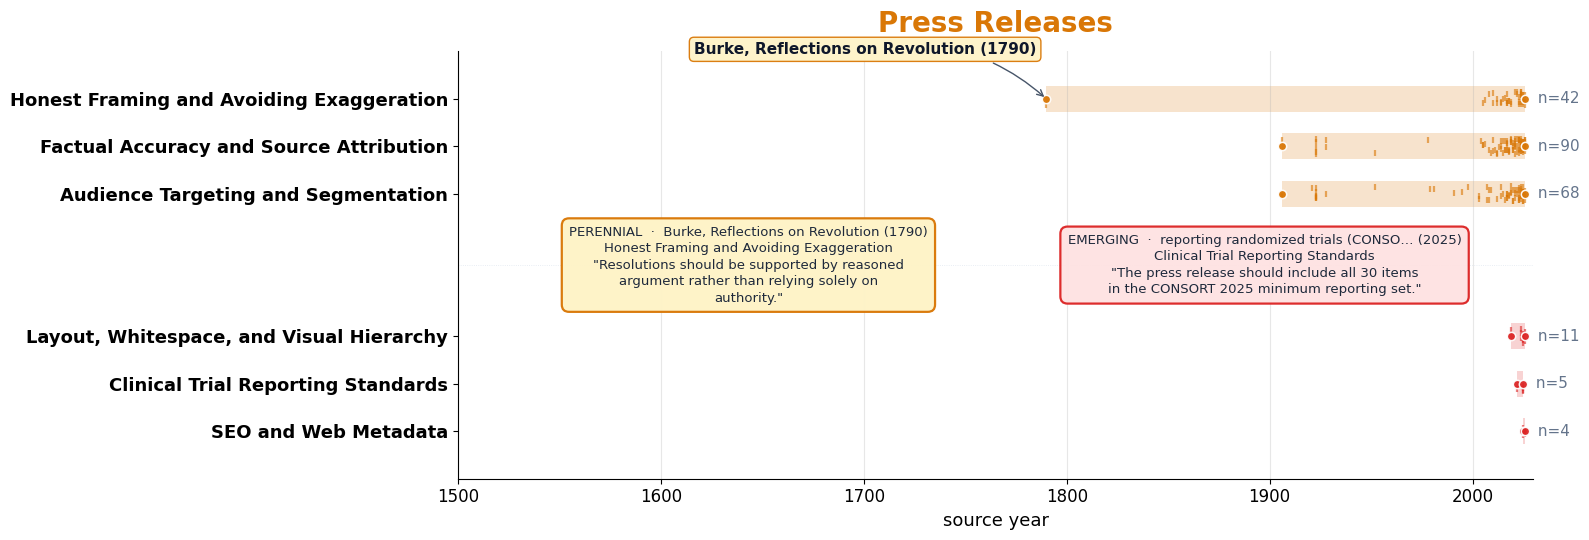

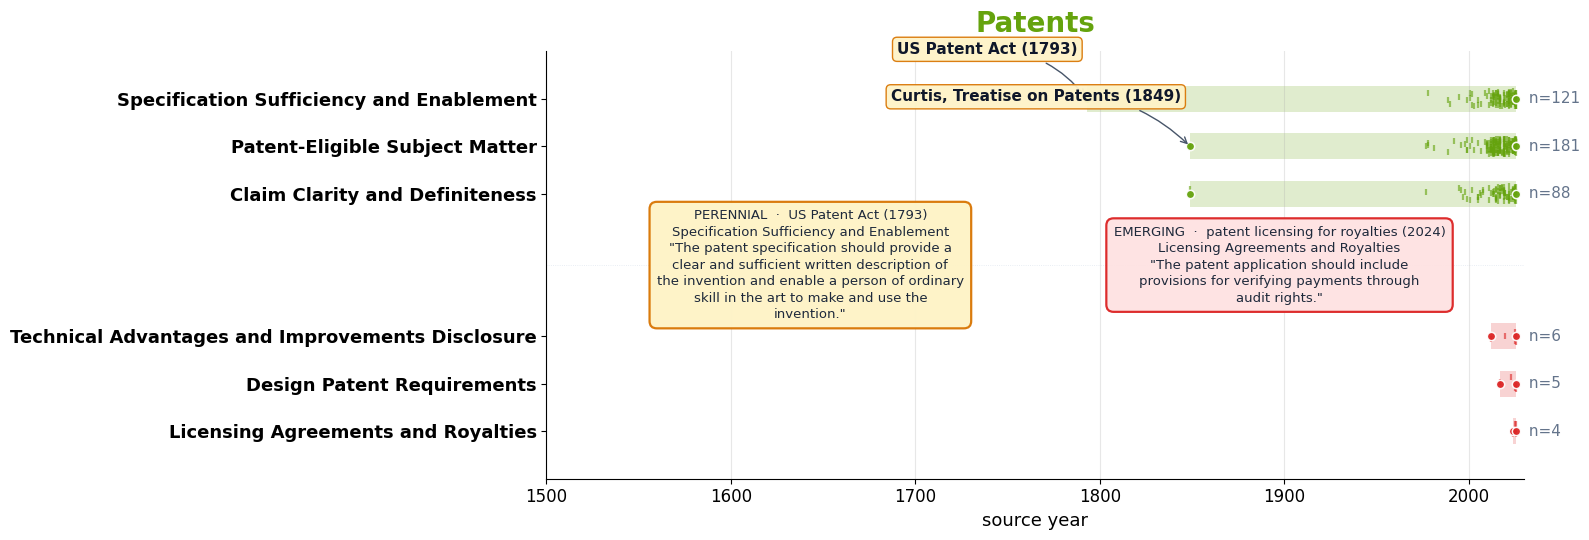

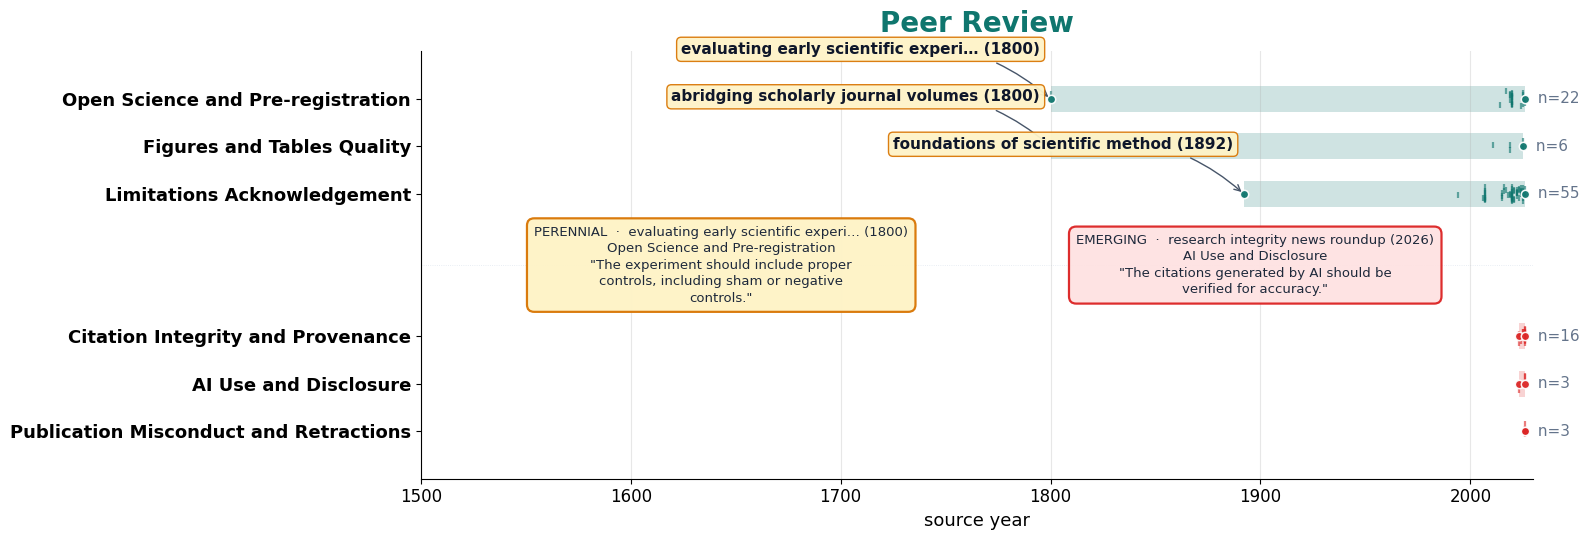

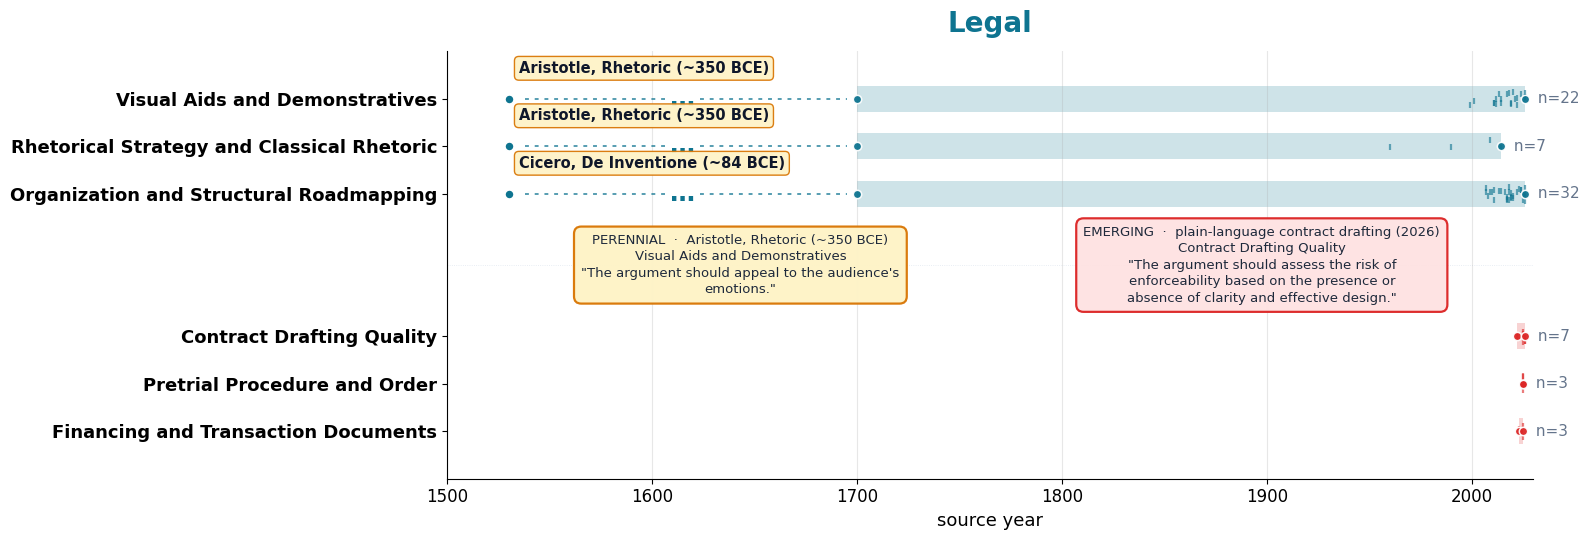

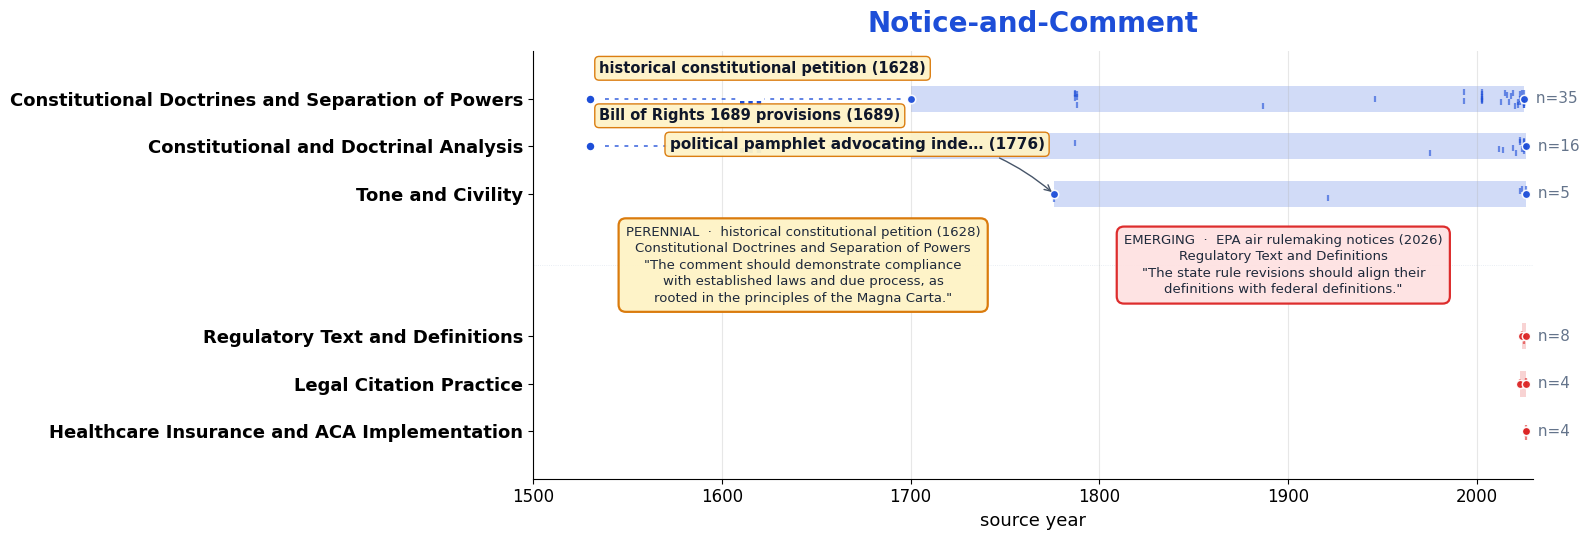

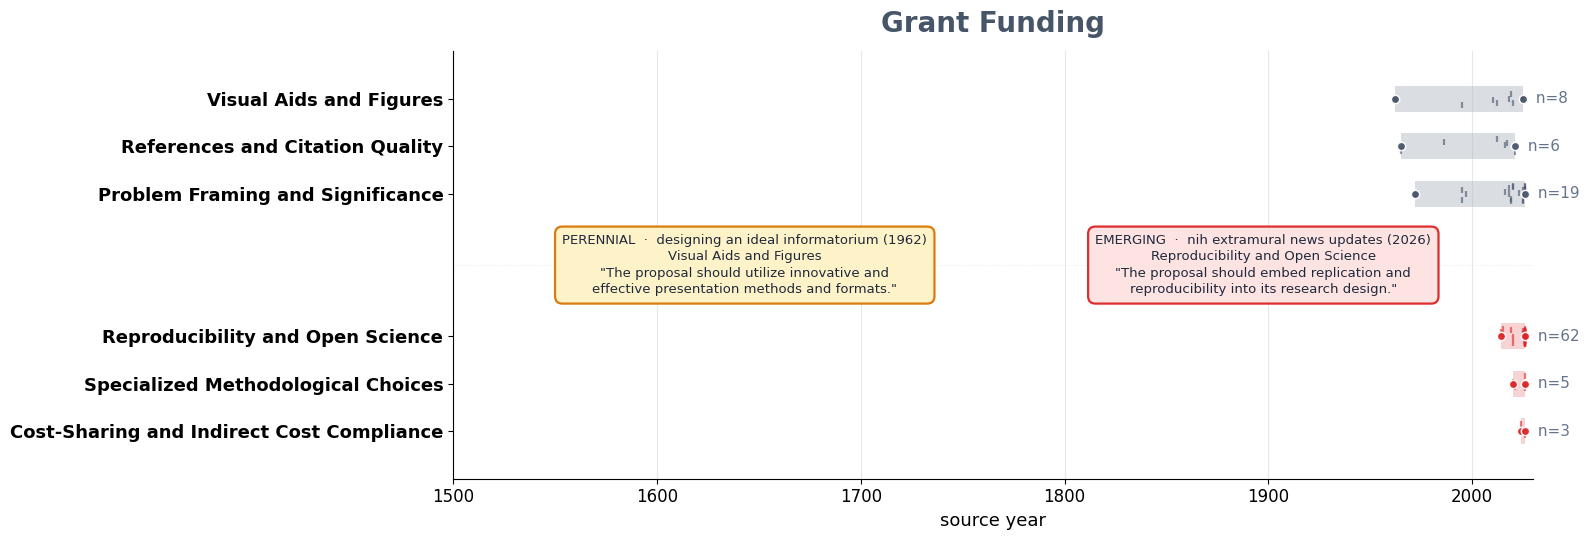

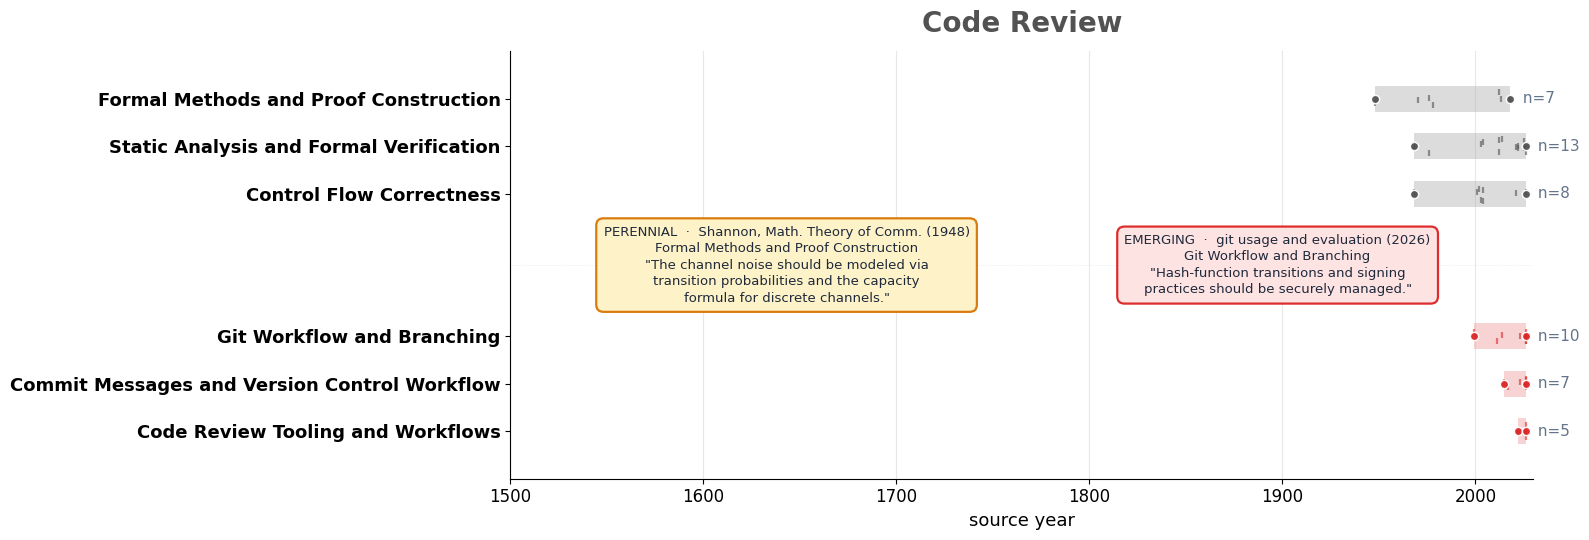

In [577]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import textwrap
import numpy as np
import pandas as pd
from pathlib import Path
import json
from collections import defaultdict

ROOT = Path('/Users/spangher/Projects/stanford-research/norm-research')
R2A = ROOT / 'outputs/r2_attr_labeling/agg'
ANAL = ROOT / 'outputs/analyses'
SM = ROOT / 'outputs/analyses/structural_metrics'

mentions = pd.read_parquet(R2A / 'r2_aspect_year_mentions_distinct_sources.parquet')
pages_meta = pd.read_parquet(ROOT / 'notebooks/_explore_cache/pages.parquet')
pages_meta = pages_meta[['task','source_file','subtask_short']].drop_duplicates()

# ----- Quote lookup -----
_key_to_canon, _key_to_src, _key_to_page = {}, {}, {}
for line in open(ANAL / 'canon_all_real_forms.jsonl'):
    o = json.loads(line); _key_to_canon[o['key']] = o['canonical']
    parts = o['key'].split('::')
    if len(parts) >= 3: _key_to_src[o['key']] = parts[2]
    if len(parts) >= 2: _key_to_page[o['key']] = o['key'].rsplit('::', 1)[0]
_page_to_year = {}
for line in open(ANAL / 'source_years.jsonl'):
    o = json.loads(line)
    if o.get('year') is not None and o.get('year_confidence', 0) >= 2:
        _page_to_year[o['page_id']] = o['year']

_task_cache = {}
def _get_task_data(task):
    if task not in _task_cache:
        clusters = json.load(open(SM / f'clusters_{task}.json'))
        ck = defaultdict(list)
        for k, c in clusters.items(): ck[c].append(k)
        r1 = json.load(open(SM / 'r1_v4a_lora_fork3_merge' / f'r1_families_{task}.json'))
        r2 = json.load(open(SM / 'r2_v1_subagent' / f'r2_aspects_{task}.json'))
        _task_cache[task] = (ck, r1['families'], {a['aspect_id']: a for a in r2['aspects']})
    return _task_cache[task]

def _all_quotes(task, aspect_id):
    ck, fams, asps = _get_task_data(task)
    a = asps.get(aspect_id)
    if not a: return []
    out, seen = [], set()
    for fid in a.get('family_ids', []):
        if not (0 <= fid < len(fams)): continue
        for cid in fams[fid].get('cluster_ids', []):
            for k in ck.get(cid, []):
                if k in seen: continue
                seen.add(k)
                y = _page_to_year.get(_key_to_page.get(k))
                c = _key_to_canon.get(k); s = _key_to_src.get(k)
                if y is None or c is None: continue
                out.append((y, s, c))
    return sorted(out)

_NEWNESS_KW = ['ai ', 'ai,', 'ai.', 'ai-', 'ai/', 'artificial intelligence', 'llm', 'gpt',
               'chatgpt', 'generative', 'machine learning', 'algorithmic',
               'open access', 'open data', 'fair principle', 'preregistration',
               'data sharing', 'reproducibility', 'esg', 'sustainability', 'climate',
               'gdpr', 'wcag', 'accessibility', 'consort 2', 'open science',
               'cybersecurity', 'diversity', 'inclusiv', 'equity', 'cloud',
               'replicab', 'verifiab', 'audit right', 'fairness']
def _score_newness(t):
    t = t.lower()
    return sum(1 for k in _NEWNESS_KW if k in t)

def _pick_quote(task, aspect_id, mode):
    q = _all_quotes(task, aspect_id)
    if not q: return None
    if mode == 'oldest':
        return q[0]
    recent = [x for x in q if x[0] >= 2020] or q[-3:]
    scored = [(_score_newness(c), y, s, c) for y, s, c in recent]
    scored.sort(key=lambda x: (-x[0], -x[1]))
    _, y, s, c = scored[0]
    return (y, s, c)

TASKS_KEBAB = [
    'math-stackexchange', 'creative-writing', 'humor', 'news-homepages',
    'press-releases', 'patents', 'peer-review', 'legal-outcome-prediction',
    'notice-and-comment', 'grant-funding', 'code-review',
]
TASK_COLOR = {
    'math-stackexchange':       '#9333ea',
    'creative-writing':         '#7c3aed',
    'humor':                    '#be185d',
    'news-homepages':           '#dc2626',
    'press-releases':           '#d97706',
    'patents':                  '#65a30d',
    'peer-review':              '#0f766e',
    'legal-outcome-prediction': '#0e7490',
    'notice-and-comment':       '#1d4ed8',
    'grant-funding':            '#475569',
    'code-review':              '#525252',
}
EMERGING_COLOR = '#dc2626'
PERENNIAL_TINT  = '#fef3c7'   # warm gold card fill
PERENNIAL_EDGE  = '#d97706'
EMERGING_TINT   = '#fee2e2'   # pale red card fill
EMERGING_EDGE   = '#dc2626'
TASK_TITLE = {
    'math-stackexchange':       'Mathematics',
    'creative-writing':         'Creative Writing',
    'humor':                    'Humor',
    'news-homepages':           'News',
    'press-releases':           'Press Releases',
    'patents':                  'Patents',
    'peer-review':              'Peer Review',
    'legal-outcome-prediction': 'Legal',
    'notice-and-comment':       'Notice-and-Comment',
    'grant-funding':            'Grant Funding',
    'code-review':              'Code Review',
}

SOURCE_LABELS = {
    'aristotle_poetics.md':                            'Aristotle, Poetics (~335 BCE)',
    'aristotle_rhetoric_forensic.md':                  'Aristotle, Rhetoric (~350 BCE)',
    'aristotle_tragic_concepts.md':                    'Aristotle, Poetics (~335 BCE)',
    'horace_ars_poetica.md':                           'Horace, Ars Poetica (~19 BCE)',
    'cicero_de_inventione_stasis.md':                  'Cicero, De Inventione (~84 BCE)',
    'cicero_de_oratore_ideal_orator.md':               'Cicero, De Oratore (55 BCE)',
    'quintilian_institutio_oratoria.md':               'Quintilian, Institutio Oratoria (~95 CE)',
    'quintilian_urbanitas_humor_decorum.md':           'Quintilian, Institutio Oratoria (~95 CE)',
    'quintilian_five_canons.md':                       'Quintilian, Institutio Oratoria (~95 CE)',
    'waveh4_8956e011a2d2.html':                        'Bacon, Novum Organum (1620)',
    'coke_institutes_artificial_reason.md':            'Coke, Institutes (1628)',
    'waveh4_41ab1ef3f138.html':                        'Milton, Areopagitica (1644)',
    'hobbes_sudden_glory_superiority.md':              'Hobbes, Leviathan (1651)',
    'kant_strained_expectation_nothing.md':            'Kant, Critique of Judgment (1790)',
    'waveh4_88c0d9dd293b.html':                        'Burke, Reflections on Revolution (1790)',
    'waveh4_53c86aaf32ed.html':                        'US Patent Act (1793)',
    'waveh3_ia_curtis_patents.html':                   'Curtis, Treatise on Patents (1849)',
    'waveh3_gutenberg_pulitzer_school_journalism_18625.html': 'Pulitzer School (1922)',
    'waveh5_lippmann_liberty_news_gutenberg.txt':      'Lippmann, Liberty & News (1877)',
    'ivy_lee_1906_declaration_of_principles.md':       'Ivy Lee, Declaration (1906)',
    'bernays_crystallizing_public_opinion_principles.md': 'Bernays, Crystallizing P.O. (1923)',
    'lippmann_public_opinion_news_criteria.md':        'Lippmann, Public Opinion (1922)',
    'waveh3_gutenberg_shannon_mathematical_theory_archive.html': 'Shannon, Math. Theory of Comm. (1948)',
    'dijkstra_structured_programming.md':              'Dijkstra, Structured Programming (1968)',
    'waveh5_nato_garmisch_1968.pdf':                   'NATO Garmisch (1968)',
}

TOP_N_OLD = 3
TOP_N_NEW = 3
GAP = 2.0               # gap to host the two cards
XMIN_VISUAL, XMAX = 1500, 2030
ANCIENT_THRESHOLD = 1700
ANCIENT_X = 1530


def _source_label(task, source_file, year):
    if source_file in SOURCE_LABELS:
        return SOURCE_LABELS[source_file]
    pg = pages_meta[(pages_meta.task == task) & (pages_meta.source_file == source_file)]
    st = (pg.iloc[0]['subtask_short'] if len(pg) and pg.iloc[0]['subtask_short'] else '')
    if st:
        st = st.replace('_', ' ')
        if len(st) > 36:
            st = st[:34] + '…'
        return f'{st} ({int(year)})'
    return f'({int(year)})'


def _draw_card(ax, x_center, y_center, header_text, aspect_text, quote_text,
               fill, edge):
    """Draw a styled callout card centered at (x_center, y_center) in data coords.
    Uses ax.text with bbox so the box auto-sizes to text and ignores axis inversion."""
    wrapped_quote = textwrap.fill(f'"{quote_text}"', width=46)
    body = f"{header_text}\n{aspect_text}\n{wrapped_quote}"
    ax.text(x_center, y_center, body,
            fontsize=9.5, color='#1e293b', va='center', ha='center',
            linespacing=1.35,
            bbox=dict(boxstyle='round,pad=0.55', facecolor=fill,
                      edgecolor=edge, linewidth=1.6, alpha=0.97),
            zorder=12)


def plot_task_longevity(task, n_old=TOP_N_OLD, n_new=TOP_N_NEW, gap=GAP, max_anno=3):
    sub = mentions[mentions.task == task]
    if len(sub) == 0:
        return
    g = sub.groupby(['aspect_id', 'aspect_name']).agg(
        min_y=('year', 'min'), max_y=('year', 'max'),
        median_y=('year', 'median'), n_src=('year', 'size')).reset_index()
    g['span'] = g['max_y'] - g['min_y']

    old = g[g.n_src >= 5].sort_values(['span','n_src'], ascending=False).head(n_old).copy()
    old = old.sort_values('min_y')
    new_pool = g[(g.median_y >= 2022) & (g.n_src >= 3) & (~g.aspect_id.isin(old.aspect_id))]
    new = new_pool.sort_values(['median_y','n_src'], ascending=False).head(n_new).copy()
    new = new.sort_values('median_y')

    if len(old) == 0 and len(new) == 0:
        return

    n_rows = len(old) + len(new)
    # Back to original-ish height; the cards live in the gap so we don't grow vertically.
    fig, ax = plt.subplots(figsize=(16, max(4.5, 0.75 * n_rows + 1.0)))
    color = TASK_COLOR[task]

    y_old = list(range(len(old)))
    y_new = [len(old) + gap + i for i in range(len(new))]
    y_max = (y_new[-1] if y_new else (y_old[-1] if y_old else 0))

    def _draw_row(y, r, bar_color):
        bar_min = max(r['min_y'], ANCIENT_THRESHOLD)
        ax.barh(y, r['max_y'] - bar_min, left=bar_min, height=0.55,
                color=bar_color, alpha=0.20, linewidth=0)
        yrs = sub[sub.aspect_id == r['aspect_id']]['year'].values
        modern_yrs = yrs[yrs >= ANCIENT_THRESHOLD]
        rng = np.random.default_rng(hash(r['aspect_id']) % 2**32)
        jitter = (rng.random(len(modern_yrs)) - 0.5) * 0.32
        ax.scatter(modern_yrs, np.full(len(modern_yrs), y) + jitter, s=20, color=bar_color,
                   alpha=0.6, marker='|', linewidths=1.6)
        ax.scatter([bar_min, r['max_y']], [y, y], s=36, color=bar_color,
                   alpha=0.95, marker='o', edgecolor='white', linewidth=1.1, zorder=5)
        ax.text(r['max_y'] + 4, y, f" n={int(r['n_src'])}", va='center',
                fontsize=11, color='#64748b')

        # Anachronistic ancient-source callout (unchanged from prior)
        if r['min_y'] < ANCIENT_THRESHOLD:
            ancient = sub[(sub.aspect_id == r['aspect_id']) &
                          (sub.year < ANCIENT_THRESHOLD)].sort_values('year').iloc[0]
            label = _source_label(task, ancient['source_file'], ancient['year'])
            ax.plot([ANCIENT_X + 8, bar_min - 5], [y, y], linestyle=(0, (2, 3)),
                    color=bar_color, alpha=0.7, linewidth=1.4, zorder=3)
            mid_x = (ANCIENT_X + bar_min) / 2
            ax.text(mid_x, y, '…', ha='center', va='center', fontsize=18,
                    color=bar_color, fontweight='bold', zorder=4,
                    bbox=dict(facecolor='white', edgecolor='none', pad=1))
            ax.scatter([ANCIENT_X], [y], s=42, color=bar_color, marker='o',
                       edgecolor='white', linewidth=1.1, zorder=6)
            ax.annotate(label, xy=(ANCIENT_X, y),
                        xytext=(ANCIENT_X + 5, y - 0.55), fontsize=10.5,
                        color='#0f172a', fontweight='bold', ha='left',
                        bbox=dict(facecolor='#fef3c7', edgecolor='#d97706',
                                  alpha=0.95, boxstyle='round,pad=0.3'),
                        zorder=10)

    for y, (_, r) in zip(y_old, old.iterrows()):
        _draw_row(y, r, color)
    for y, (_, r) in zip(y_new, new.iterrows()):
        _draw_row(y, r, EMERGING_COLOR)

    # ----- Cards: one perennial highlight + one emerging highlight in the gap -----
    if len(old) > 0 and len(new) > 0:
        mid_y = (y_old[-1] + y_new[0]) / 2
        # subtle divider
        ax.axhline(mid_y, color='#e2e8f0', linewidth=0.6, linestyle=':', zorder=1)

        # Pick the most striking perennial (smallest min_y) and emerging (highest newness)
        per_pick = old.sort_values('min_y').iloc[0]
        per_q = _pick_quote(task, per_pick['aspect_id'], 'oldest')

        emg_q_choices = []
        for _, rr in new.iterrows():
            q = _pick_quote(task, rr['aspect_id'], 'emerging')
            if q is None: continue
            emg_q_choices.append((rr, q, _score_newness(q[2]), q[0]))
        emg_q_choices.sort(key=lambda x: (-x[2], -x[3]))
        emg_pick, emg_q = (emg_q_choices[0][0], emg_q_choices[0][1]) if emg_q_choices else (None, None)

        # Two cards side-by-side, centered horizontally
        per_cx = XMIN_VISUAL + (XMAX - XMIN_VISUAL) * 0.27   # ~ x=1643
        emg_cx = XMIN_VISUAL + (XMAX - XMIN_VISUAL) * 0.75   # ~ x=1898

        if per_q:
            per_year, per_src, per_text = per_q
            _draw_card(
                ax, per_cx, mid_y,
                header_text=f'PERENNIAL  ·  {_source_label(task, per_src, per_year)}',
                aspect_text=per_pick['aspect_name'],
                quote_text=per_text,
                fill=PERENNIAL_TINT, edge=PERENNIAL_EDGE,
            )
        if emg_q:
            emg_year, emg_src, emg_text = emg_q
            _draw_card(
                ax, emg_cx, mid_y,
                header_text=f'EMERGING  ·  {_source_label(task, emg_src, emg_year)}',
                aspect_text=emg_pick['aspect_name'],
                quote_text=emg_text,
                fill=EMERGING_TINT, edge=EMERGING_EDGE,
            )

    # Early-modern (1700-1900) source name annotation on perennial rows (unchanged)
    annotated = 0
    used_sources = set()
    for y, (_, r) in zip(y_old, old.iterrows()):
        if not (ANCIENT_THRESHOLD <= r['min_y'] < 1900) or annotated >= max_anno:
            continue
        earliest = sub[(sub.aspect_id == r['aspect_id']) &
                       (sub.year >= ANCIENT_THRESHOLD)].sort_values('year').iloc[0]
        if earliest['source_file'] in used_sources:
            continue
        used_sources.add(earliest['source_file'])
        label = _source_label(task, earliest['source_file'], earliest['year'])
        ax.annotate(
            label, xy=(earliest['year'], y),
            xytext=(earliest['year'] - 5, y - 0.95),
            fontsize=11, color='#0f172a', fontweight='bold', ha='right',
            arrowprops=dict(arrowstyle='->', color='#475569', lw=1.0,
                            connectionstyle='arc3,rad=-0.25'),
            bbox=dict(facecolor='#fef3c7', edgecolor='#d97706', alpha=0.95,
                      boxstyle='round,pad=0.3'),
            zorder=10,
        )
        annotated += 1

    all_y = y_old + y_new
    all_names = list(old['aspect_name']) + list(new['aspect_name'])
    ax.set_yticks(all_y)
    ax.set_yticklabels([nm[:62] for nm in all_names], fontsize=13, fontweight='bold')
    ax.set_xlim(XMIN_VISUAL, XMAX)
    ax.set_ylim(y_max + 1.0, -1.0)
    ax.set_xlabel('source year', fontsize=13)
    ax.set_title(TASK_TITLE[task], fontsize=20, fontweight='bold',
                 color=color, pad=14)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


for task in TASKS_KEBAB:
    plot_task_longevity(task)
